In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm as cm
import seaborn as sns

from sklearn.impute import KNNImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("Bangladesh_Crime_Dataset_A.csv")
df.head()

,Unnamed: 0,incident_month,incident_week,incident_weekday,weekend,part_of_the_day,incident_district,incident_division,precip,visibility,...,average_household_size,density_per_kmsq,literacy_rate,religious_institution,playground,park,police_station,school,college,crime
0,0,7.0,29,wednesday,0,morning,dhaka,dhaka,6.1,10,...,8.42,30551.0,74.6,4289,99,17,60,242,64,murder
1,1,1.0,2,wednesday,0,night,dhaka,dhaka,0.0,10,...,8.42,30551.0,74.6,4289,99,17,60,242,64,murder
2,2,1.0,4,tuesday,0,night,dhaka,dhaka,0.0,10,...,8.42,30551.0,74.6,4289,99,17,60,242,64,murder
3,3,3.0,9,friday,1,night,dhaka,dhaka,0.0,10,...,8.42,30551.0,74.6,4289,99,17,60,242,64,murder
4,4,8.0,34,thursday,0,night,dhaka,dhaka,21.9,9,...,8.42,30551.0,74.6,4289,99,17,60,242,64,murder


# A) EDA + Data Preprocessing

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6574 entries, 0 to 6573
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              6574 non-null   int64  
 1   incident_month          5917 non-null   float64
 2   incident_week           6574 non-null   int64  
 3   incident_weekday        6574 non-null   object 
 4   weekend                 6574 non-null   int64  
 5   part_of_the_day         6457 non-null   object 
 6   incident_district       6246 non-null   object 
 7   incident_division       6574 non-null   object 
 8   precip                  6574 non-null   float64
 9   visibility              6574 non-null   int64  
 10  heatindex               6574 non-null   int64  
 11  season                  6574 non-null   object 
 12  male_population         6574 non-null   int64  
 13  female_population       6574 non-null   int64  
 14  total_population        6574 non-null   

Tidak ada kolom Unnamed: 0 di dataset description, selain itu valuenya sama persis dengan index sehingga bisa dikatakan ini adalah kolom redundant yang harus didrop.

Untuk tipe data sendiri sudah sesuai dengan deskripsi dataset.

In [4]:
df1 = df.drop(columns=['Unnamed: 0'])
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6574 entries, 0 to 6573
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   incident_month          5917 non-null   float64
 1   incident_week           6574 non-null   int64  
 2   incident_weekday        6574 non-null   object 
 3   weekend                 6574 non-null   int64  
 4   part_of_the_day         6457 non-null   object 
 5   incident_district       6246 non-null   object 
 6   incident_division       6574 non-null   object 
 7   precip                  6574 non-null   float64
 8   visibility              6574 non-null   int64  
 9   heatindex               6574 non-null   int64  
 10  season                  6574 non-null   object 
 11  male_population         6574 non-null   int64  
 12  female_population       6574 non-null   int64  
 13  total_population        6574 non-null   int64  
 14  gender_ration           6574 non-null   

## Check Duplicate Values

In [5]:
sum(df1.duplicated())

267

In [6]:
df1 = df1.drop_duplicates()

In [7]:
sum(df1.duplicated())

0

In [8]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6307 entries, 0 to 6573
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   incident_month          5651 non-null   float64
 1   incident_week           6307 non-null   int64  
 2   incident_weekday        6307 non-null   object 
 3   weekend                 6307 non-null   int64  
 4   part_of_the_day         6190 non-null   object 
 5   incident_district       5979 non-null   object 
 6   incident_division       6307 non-null   object 
 7   precip                  6307 non-null   float64
 8   visibility              6307 non-null   int64  
 9   heatindex               6307 non-null   int64  
 10  season                  6307 non-null   object 
 11  male_population         6307 non-null   int64  
 12  female_population       6307 non-null   int64  
 13  total_population        6307 non-null   int64  
 14  gender_ration           6307 non-null   int64

## Inconsistent Value

In [9]:
cat_col = [c for c in df1.columns if df1[c].dtype == 'object']

for c in cat_col:
    print(f"Total unique values in {c}: {df1[c].nunique()}")
    print(df1[c].value_counts(), "\n")

Total unique values in incident_weekday: 7
incident_weekday
tuesday      971
wednesday    931
monday       930
thursday     911
saturday     873
friday       852
sunday       839
Name: count, dtype: int64 

Total unique values in part_of_the_day: 5
part_of_the_day
night        3035
morning      1886
noon          484
evening       465
afternoon     320
Name: count, dtype: int64 

Total unique values in incident_district: 64
incident_district
dhaka         1064
chattogram     455
mymensingh     244
jashore        233
dinajpur       186
              ... 
magura          14
sherpur         13
shariatpur      11
kurigram        10
narail           9
Name: count, Length: 64, dtype: int64 

Total unique values in incident_division: 192
incident_division
dhaka         1717
chattogram     877
rajshahi       657
rangpur        603
khulna         585
              ... 
RAngpuR          1
rAJSHaHi         1
MyMensINgH       1
sylheT           1
cHATtOGRam       1
Name: count, Length: 192, dtype:

Terdapat inconsistent values di kolom incident_division dimana lokasi yang sama dianggap sebagai kategori yang berbeda karena adanya perbedaan huruf kapital dan spasi sehingga harus dihandle.

In [10]:
df1['incident_division'] = df1['incident_division'].str.lower().str.strip()
df1['incident_division'].value_counts()

incident_division
dhaka         1956
chattogram    1020
rajshahi       739
rangpur        680
khulna         671
mymensingh     438
sylhet         403
barisal        396
gazipur          4
Name: count, dtype: int64

In [11]:
# check kembali
cat_col = [c for c in df1.columns if df1[c].dtype == 'object']

for c in cat_col:
    print(f"Total unique values in {c}: {df1[c].nunique()}")
    print(df1[c].value_counts(), "\n")

Total unique values in incident_weekday: 7
incident_weekday
tuesday      971
wednesday    931
monday       930
thursday     911
saturday     873
friday       852
sunday       839
Name: count, dtype: int64 

Total unique values in part_of_the_day: 5
part_of_the_day
night        3035
morning      1886
noon          484
evening       465
afternoon     320
Name: count, dtype: int64 

Total unique values in incident_district: 64
incident_district
dhaka         1064
chattogram     455
mymensingh     244
jashore        233
dinajpur       186
              ... 
magura          14
sherpur         13
shariatpur      11
kurigram        10
narail           9
Name: count, Length: 64, dtype: int64 

Total unique values in incident_division: 9
incident_division
dhaka         1956
chattogram    1020
rajshahi       739
rangpur        680
khulna         671
mymensingh     438
sylhet         403
barisal        396
gazipur          4
Name: count, dtype: int64 

Total unique values in season: 3
season
rain

Karena terdapat juga categorical variable dengan tipe data int64 atau float64, kita cek juga unique value untuk memastikan tidak ada anomali atau inkonsisten

In [12]:
cat_in_num = ['incident_month', 'incident_week', 'weekend']

for i in cat_in_num:
    print(df1[i].unique(), "\n")

[ 7.  1.  3.  8.  2. nan 11.  6.  4.  5.  9. 10. 12.] 

[29  2  4  9 34  7  1 46 45 36 23 14 31 19 37  3 16 12 44 26 40 21 24 10
  5 11 35 25  8 28 32 30  6 17 20 22 18 49 51 33 43 52 15 27 38 13 42 48
 47 41 39 50 53] 

[0 1] 



Tidak ditemukan anomali atau inkonsistensi.

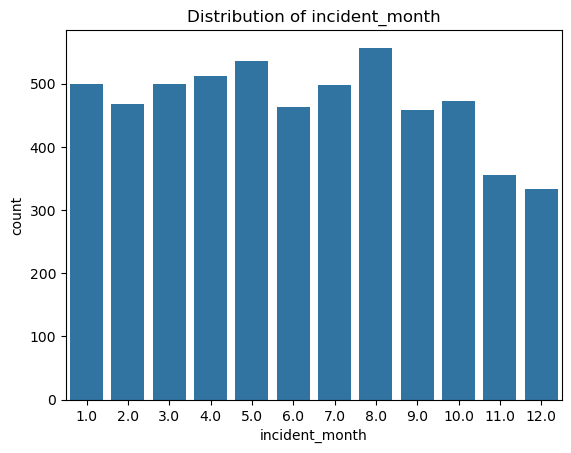

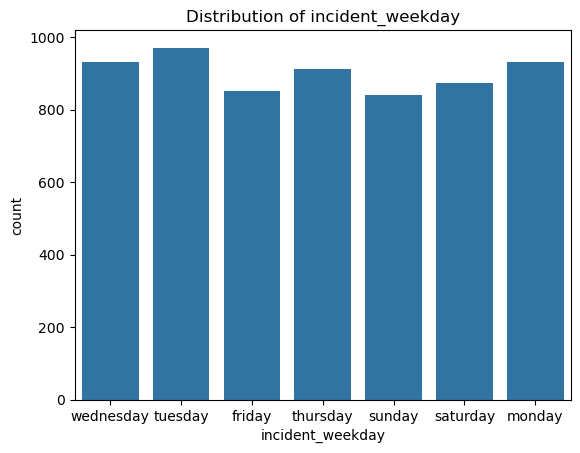

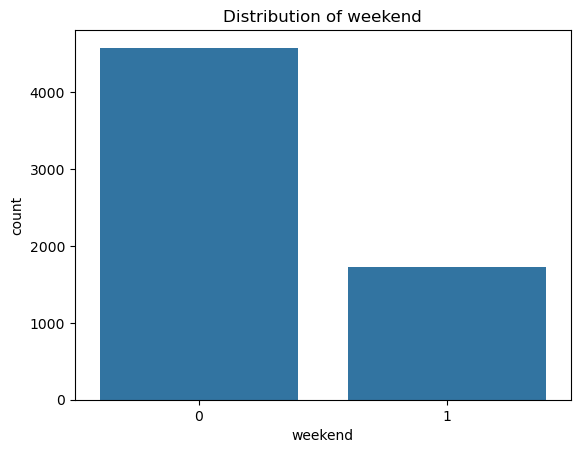

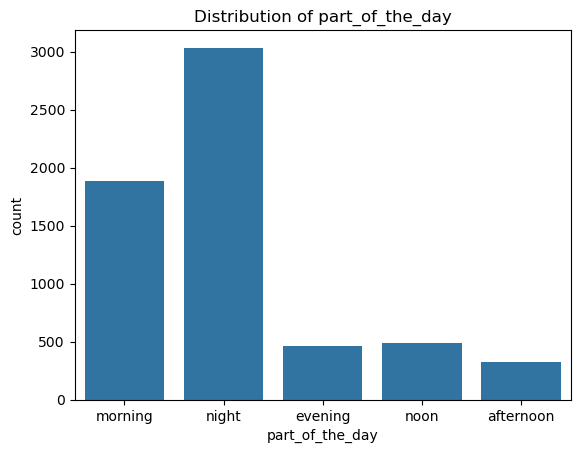

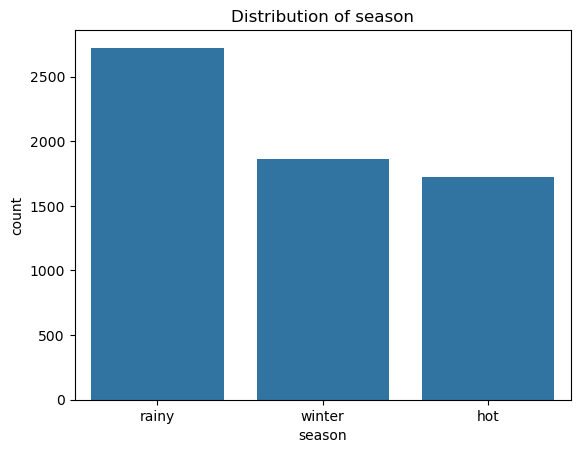

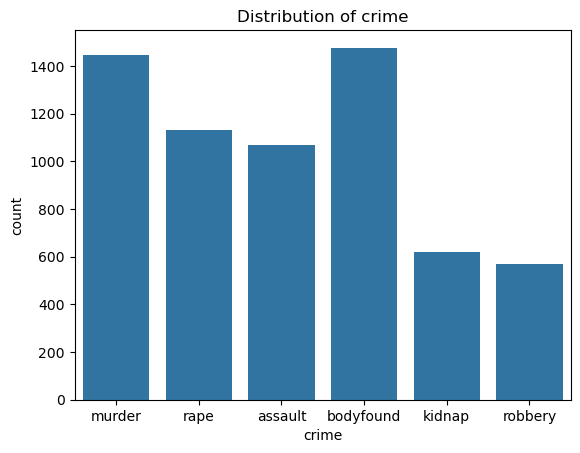

In [13]:
exc = ['incident_week', 'incident_district', 'incident_division']
cat_col2 = [c for c in df1.columns if (df1[c].dtype == 'object' or c in cat_in_num) and c not in exc]
for col in cat_col2:
    sns.countplot(data=df1, x=col)
    plt.title(f'Distribution of {col}')
    plt.show()

Distribusi kejadian antar bulan dan antar hari cukup merata, namun crime banyak terjadi di weekday (banyak frekuensi disini dipengaruhi lebih banyaknya kategori yang termasuk weekday).

Hal menarik lain, kriminalitas banyak terjadi pada malam hari diikuti oleh pagi hari. Lalu untuk seasonnya sendiri, saat musim hujan atau rainy, tingkat kriminalitas paling tinggi diantara season lainnya.

Untuk jenis kriminalitas sendiri didominasi oleh murder dan bodyfound

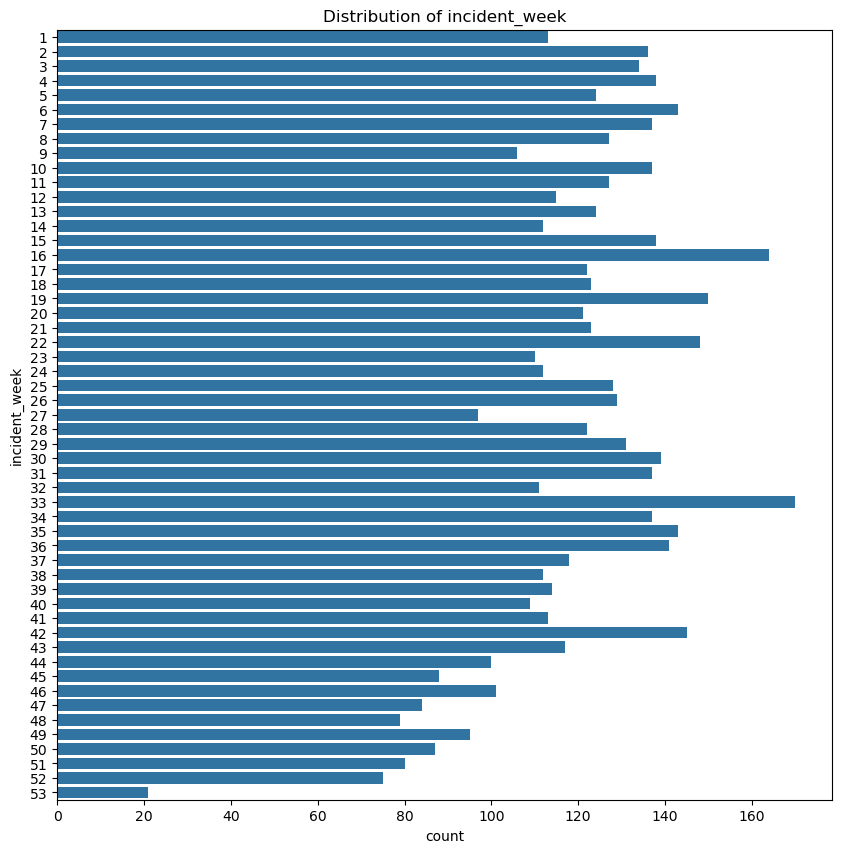

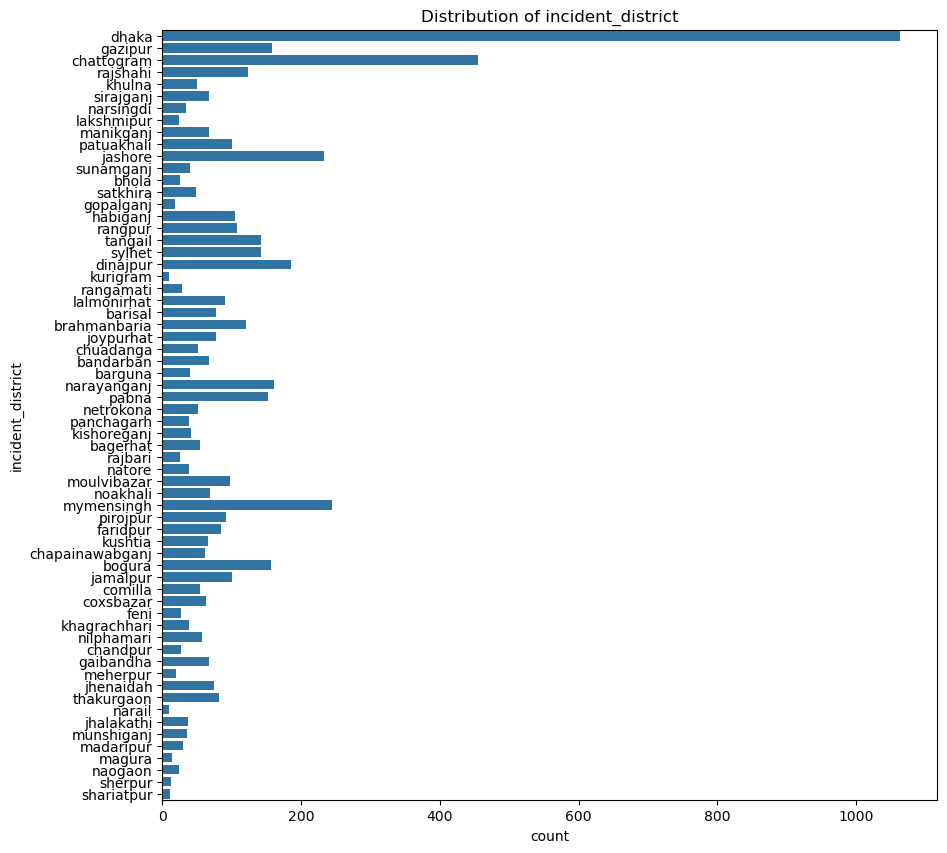

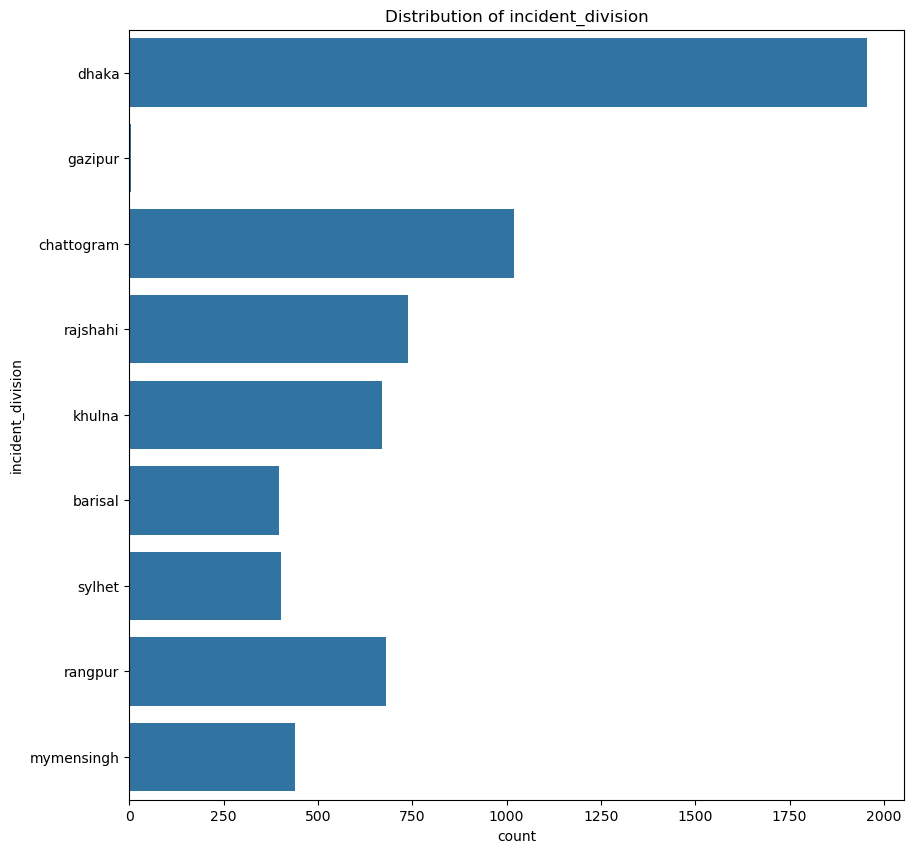

In [14]:
for col in exc:
    plt.figure(figsize = (10, 10))
    sns.countplot(data=df1, y=col)
    plt.title(f'Distribution of {col}')
    plt.show()

Dari bar plot pertama dapat terlihat bahwa incident banyak terjadi di sekitar minggu ke 33 atau di minggu pertama bulan September. Lalu dari plot kedua dan ketiga dapat terlihat jelas kalau dataset ini didominasi oleh kejadian yang terjadi di district dan division Dhaka. Mengindikasikan tingkat keamanan yang cukup rendah di sana.

## Check Numeric Column

In [15]:
df1.describe(exclude = 'object')

,incident_month,incident_week,weekend,precip,visibility,heatindex,male_population,female_population,total_population,gender_ration,average_household_size,density_per_kmsq,literacy_rate,religious_institution,playground,park,police_station,school,college
count,5651.000000,6307.000000,6307.000000,6307.000000,6307.000000,6307.000000,6.307000e+03,6.307000e+03,6.307000e+03,6307.000000,6307.000000,6.307000e+03,5979.000000,6307.000000,6307.000000,6307.000000,6307.000000,6307.000000,6307.000000
mean,6.220315,25.228159,0.273506,6.197431,9.488029,31.603456,8.938247e+05,7.547996e+05,1.648636e+06,104.432694,4.962616,1.971274e+52,55.814752,1231.786269,42.805930,3.876169,11.762962,75.428413,15.487871
std,3.315149,14.504451,0.445793,12.049128,0.923308,5.493693,1.602826e+06,1.282287e+06,2.884971e+06,10.399643,1.421478,1.382871e+54,12.053521,1243.124660,45.100892,5.884692,19.585082,71.605970,19.684628
min,1.000000,1.000000,0.000000,0.000000,4.000000,15.000000,1.132000e+04,1.124700e+04,2.287100e+04,84.000000,3.580000,5.615431e-61,26.700000,0.000000,0.000000,0.000000,-1.000000,1.000000,0.000000
25%,3.000000,13.000000,0.000000,0.000000,9.000000,27.000000,1.319300e+05,1.339960e+05,2.654610e+05,98.000000,4.110000,9.180000e+02,47.000000,519.000000,5.000000,0.000000,2.000000,30.000000,4.000000
50%,6.000000,25.000000,0.000000,0.800000,10.000000,33.000000,1.882750e+05,1.882750e+05,3.801070e+05,101.000000,4.440000,1.239000e+03,53.900000,818.000000,25.000000,1.000000,3.000000,45.000000,8.000000
75%,9.000000,37.000000,1.000000,7.500000,10.000000,36.000000,3.917070e+05,3.840260e+05,7.757330e+05,109.000000,5.080000,4.318000e+03,67.700000,1125.000000,78.000000,3.000000,6.000000,86.000000,15.000000
max,12.000000,53.000000,1.000000,204.600000,10.000000,43.000000,4.931802e+06,3.974237e+06,8.906039e+06,203.000000,8.420000,1.090315e+56,74.600000,4289.000000,253.000000,17.000000,74.000000,242.000000,64.000000


Jika dilihat dari hasil describe untuk numerical column, nilai min untuk police_station negatif. Padahal variable police_station merepresentasikan jumlah kantor polisi di suatu daerah dimana tidak bisa negatif, sehingga harus ditangani

In [16]:
df1[df1['police_station']<0]

,incident_month,incident_week,incident_weekday,weekend,part_of_the_day,incident_district,incident_division,precip,visibility,heatindex,...,average_household_size,density_per_kmsq,literacy_rate,religious_institution,playground,park,police_station,school,college,crime
27,11.0,44,saturday,1,night,dhaka,dhaka,28.0,8,26,...,8.42,30551.0,74.6,4289,99,17,-1,242,64,murder


Karena hanya ada satu row dari 6307 rows, kita akan drop row saja.

In [17]:
df2 = df1[df1['police_station']>=0]
df2.describe(exclude='object')

,incident_month,incident_week,weekend,precip,visibility,heatindex,male_population,female_population,total_population,gender_ration,average_household_size,density_per_kmsq,literacy_rate,religious_institution,playground,park,police_station,school,college
count,5650.000000,6306.000000,6306.000000,6306.000000,6306.000000,6306.000000,6.306000e+03,6.306000e+03,6.306000e+03,6306.000000,6306.000000,6.306000e+03,5978.000000,6306.000000,6306.000000,6306.000000,6306.000000,6306.000000,6306.000000
mean,6.219469,25.225182,0.273390,6.193974,9.488265,31.604345,8.931843e+05,7.542891e+05,1.647485e+06,104.429432,4.962068,1.971587e+52,55.811609,1231.301459,42.797019,3.874088,11.764986,75.401998,15.480178
std,3.314832,14.503675,0.445735,12.046954,0.923191,5.493675,1.602146e+06,1.281747e+06,2.883751e+06,10.397242,1.420923,1.382981e+54,12.052080,1242.626807,45.098915,5.882837,19.585975,71.580911,19.676705
min,1.000000,1.000000,0.000000,0.000000,4.000000,15.000000,1.132000e+04,1.124700e+04,2.287100e+04,84.000000,3.580000,5.615431e-61,26.700000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,3.000000,13.000000,0.000000,0.000000,9.000000,27.000000,1.319300e+05,1.339960e+05,2.654610e+05,98.000000,4.110000,9.180000e+02,47.000000,519.000000,5.000000,0.000000,2.000000,30.000000,4.000000
50%,6.000000,25.000000,0.000000,0.800000,10.000000,33.000000,1.882750e+05,1.882750e+05,3.801070e+05,101.000000,4.440000,1.239000e+03,53.900000,818.000000,25.000000,1.000000,3.000000,45.000000,8.000000
75%,9.000000,37.000000,1.000000,7.500000,10.000000,36.000000,3.917070e+05,3.840260e+05,7.757330e+05,109.000000,5.080000,4.318000e+03,67.575000,1125.000000,78.000000,3.000000,6.000000,86.000000,15.000000
max,12.000000,53.000000,1.000000,204.600000,10.000000,43.000000,4.931802e+06,3.974237e+06,8.906039e+06,203.000000,8.420000,1.090315e+56,74.600000,4289.000000,253.000000,17.000000,74.000000,242.000000,64.000000


In [18]:
num_col = [c for c in df2.columns if df2[c].dtype != 'object' and c not in cat_in_num]

for c in num_col:
    q1 = df2[c].quantile(0.25)
    q3 = df2[c].quantile(0.75)
    iqr = q3-q1

    lb = q1 - 1.5*iqr
    ub = q3 + 1.5*iqr

    outlier = df2[(df2[c] < lb) | (df2[c] > ub)]
    out_count = outlier.shape[0]
    perc = (out_count/df2.shape[0])*100

    print(f"Outlier in {c}: {out_count} ({perc:.2f}%)")
    print(outlier[c])
    print("\n")


Outlier in precip: 658 (10.43%)
4       21.9
35      35.7
39      27.2
69      50.4
71      19.1
        ... 
6518    39.3
6519    21.0
6546    33.6
6550    20.5
6556    20.6
Name: precip, Length: 658, dtype: float64


Outlier in visibility: 306 (4.85%)
35      7
69      6
196     6
211     7
231     7
       ..
6508    5
6510    6
6511    7
6518    7
6546    7
Name: visibility, Length: 306, dtype: int64


Outlier in heatindex: 0 (0.00%)
Series([], Name: heatindex, dtype: int64)


Outlier in male_population: 1205 (19.11%)
0       4931802
1       4931802
2       4931802
3       4931802
4       4931802
         ...   
6410     976683
6431     976683
6453     976683
6464     976683
6482     976683
Name: male_population, Length: 1205, dtype: int64


Outlier in female_population: 1205 (19.11%)
0       3974237
1       3974237
2       3974237
3       3974237
4       3974237
         ...   
6410     843691
6431     843691
6453     843691
6464     843691
6482     843691
Name: female_population,

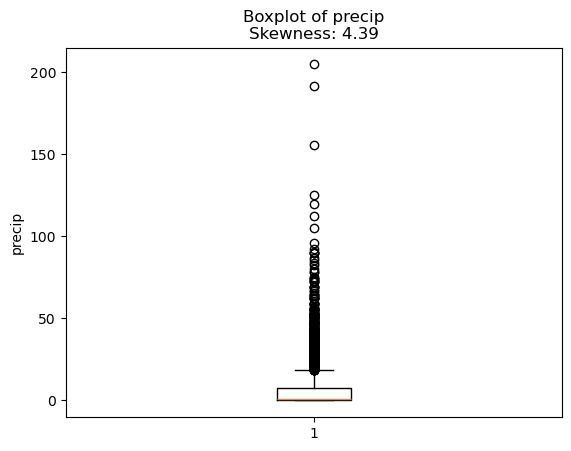

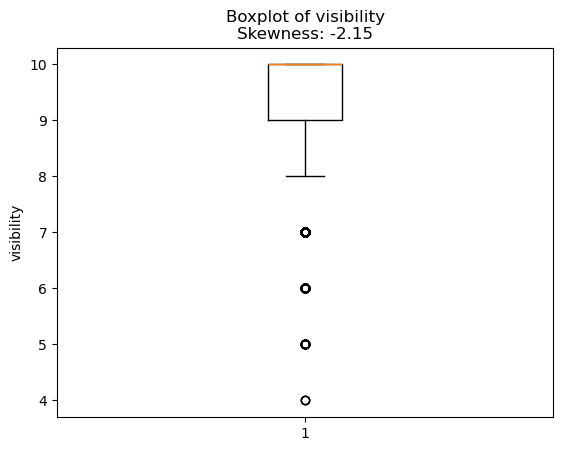

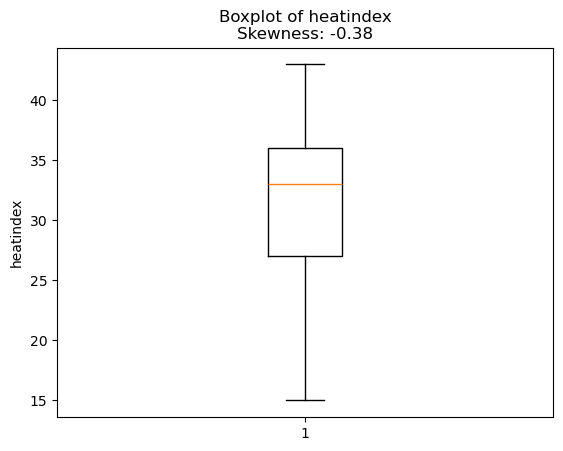

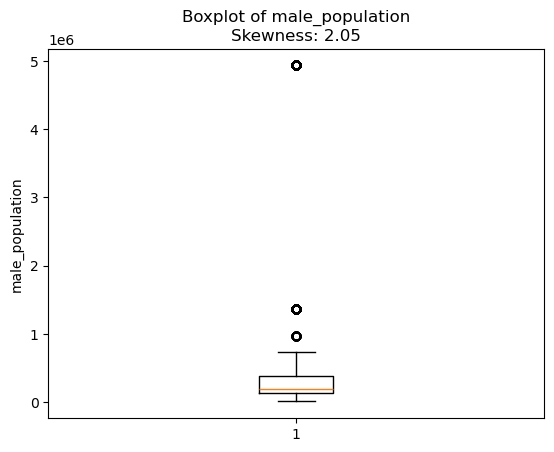

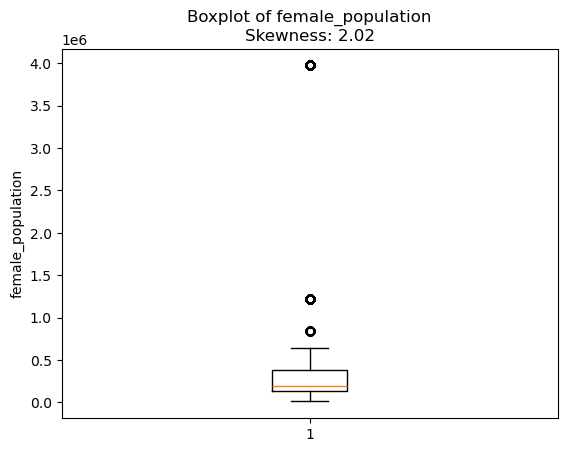

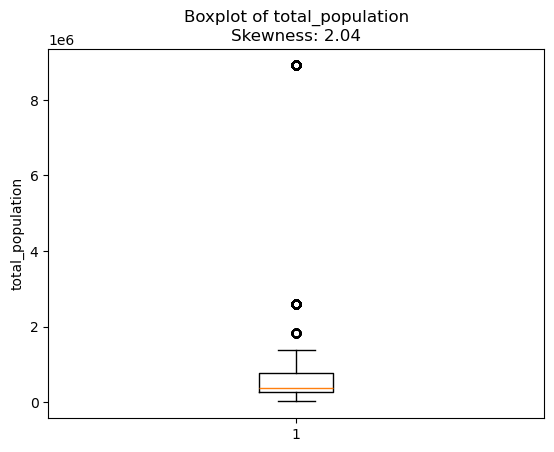

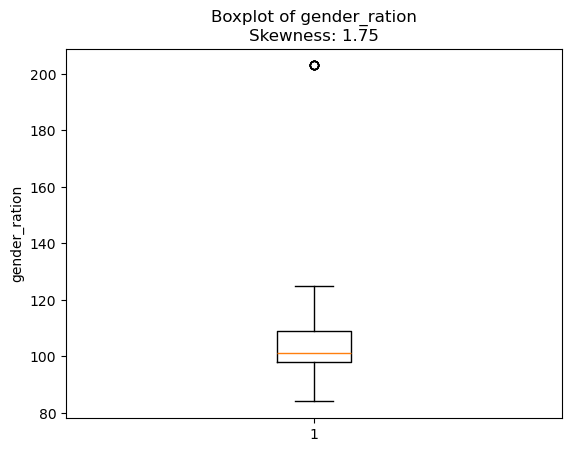

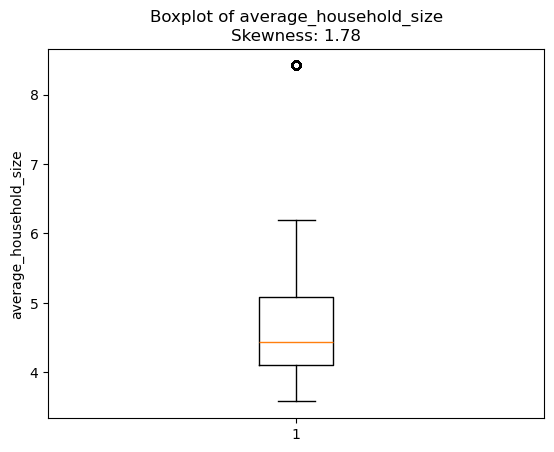

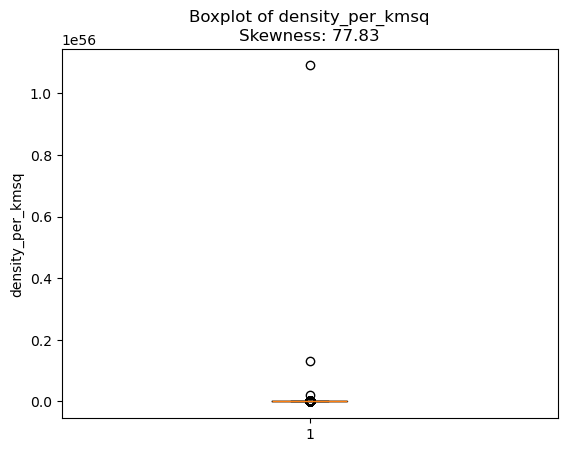

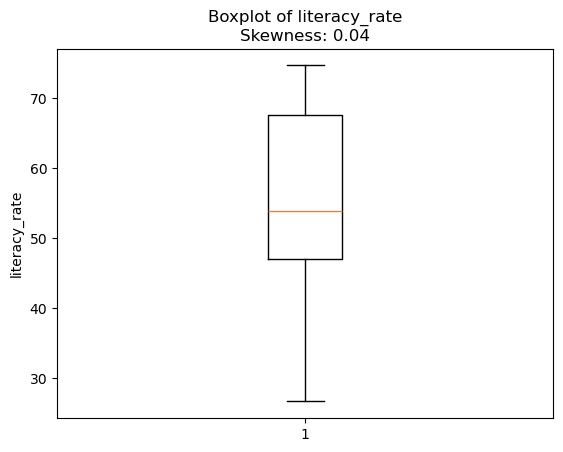

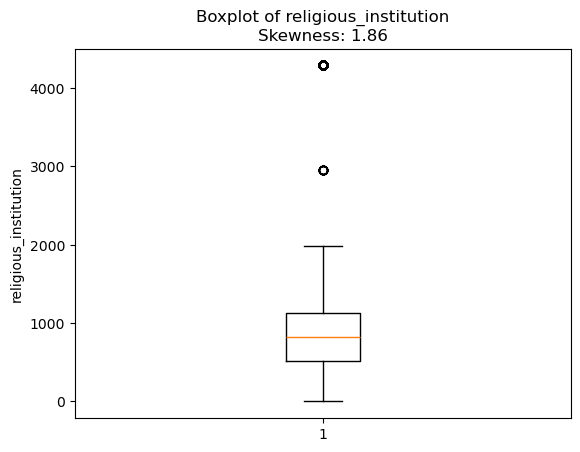

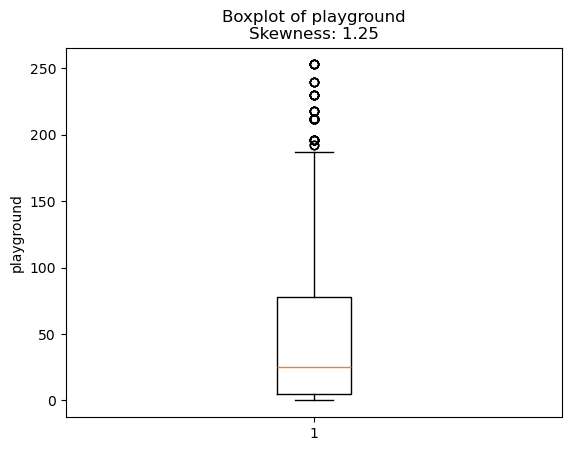

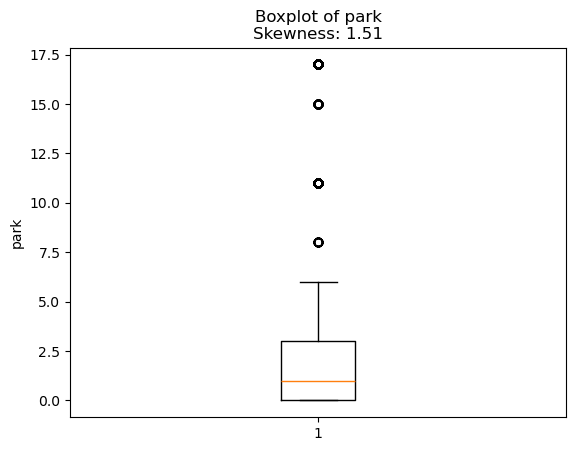

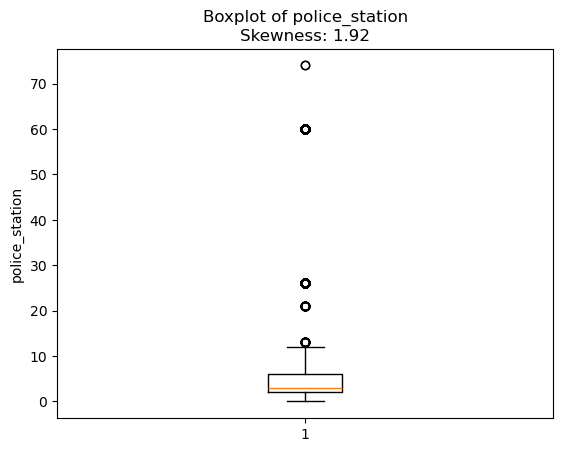

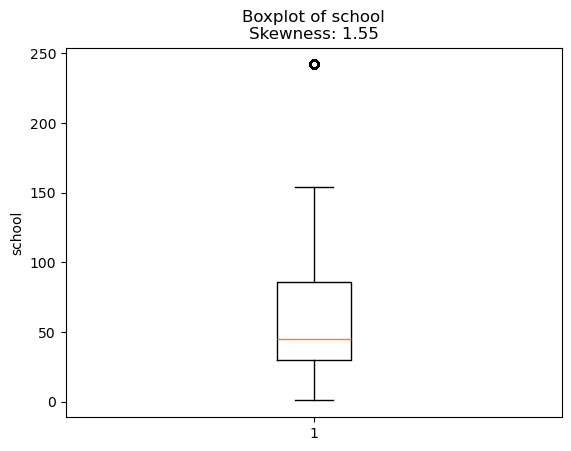

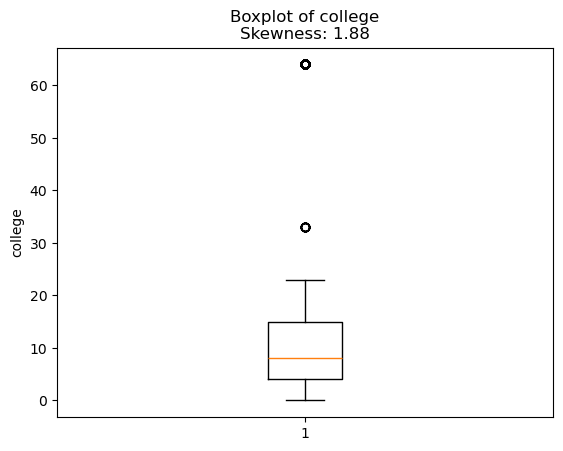

In [19]:
for col in num_col:
    skew_val = df2[col].skew()
    plt.boxplot(df2[col].dropna())
    plt.title(f'Boxplot of {col}\nSkewness: {skew_val:.2f}')
    plt.ylabel(col)
    plt.show()

Hampir semua variable numeric (kecuali density_per_kmsq) meski memiliki outlier, namun masih dalam range domain yang normal, sehingga tidak perlu ditangani. Jika dilihat dari skewness, hampir semua memiliki skewness cukup tinggi. Untuk numeric yang memiliki skewness >1 perlu dilakukan log transformation karena kmeans sensitif terhadap outlier dan distribusi skewed. Namun utk visibility karena left skewed, log transformation tidak bisa dilakukan. Sehingga yg di log transform adalah semua fitur numerik kecuali visibility serta 
literacy_rate dan heatindex (distribusi keduanya cukup simetris).

Untuk density_per_kmsq jika kita lihat di hasil describe() terlihat bahwa nilai min berada di 5.615431e-61 dimana hampir bisa dibilang 0 dan nilai maksimum 1.090315e+56 dimana cukup mustahil dalam 1km<sup>2</sup> ada lebih dari triliunan penduduk. Ini mengindikasikan adanya data noise atau data error. Hal ini juga terlihat jelas ketika kita membandingkan nilai maks total populasi dengan nilai max density dimana maksimum populasi hanya sekitar 8-9 juta jiwa. Jika total populasi saja segitu, density tidak mungkin mencapai 10<sup>56</sup>.

Oleh karena itu, data yang terindikasi sebagai noise perlu ditangani. Pada proyek ini, saya menggunakan rentang 30 hingga 60.000 jiwa per km<sup>2</sup> sebagai batas nilai kepadatan penduduk yang masih masuk akal. Rentang ini dipilih berdasarkan kondisi nyata, di mana kepadatan penduduk di wilayah pedesaan umumnya relatif rendah (50-100 jiwa/km<sup>2</sup>), sedangkan di wilayah perkotaan atau kabupaten cenderung padat (40000-50000 jiwa/km<sup>2</sup>). Sebagai bentuk toleransi terhadap kemungkinan adanya wilayah yang sangat jarang penduduk ataupun sangat padat, batas atas diperluas dari 30 hingga 60.000 jiwa per km<sup>2</sup>. 

In [20]:
df2[(df2['density_per_kmsq'] < 30) | (df2['density_per_kmsq'] > 60000)]

,incident_month,incident_week,incident_weekday,weekend,part_of_the_day,incident_district,incident_division,precip,visibility,heatindex,...,average_household_size,density_per_kmsq,literacy_rate,religious_institution,playground,park,police_station,school,college,crime
23,NaN,31,monday,0,NaN,NaN,dhaka,10.3,9,39,...,8.42,7.016799e-11,NaN,4289,99,17,60,242,64,murder
67,2.0,7,monday,0,noon,dhaka,dhaka,0.0,10,25,...,8.42,5.951251e-38,74.6,4289,99,17,60,242,64,murder
79,NaN,19,friday,1,morning,dhaka,dhaka,3.7,10,39,...,8.42,3.503669e+40,74.6,4289,99,17,60,242,64,murder
91,NaN,18,friday,1,afternoon,dhaka,dhaka,0.1,10,37,...,8.42,4.267185e-37,74.6,4289,99,17,60,242,64,murder
152,1.0,3,wednesday,0,noon,dhaka,dhaka,0.0,10,23,...,8.42,1.392962e+10,74.6,4289,99,17,60,242,64,murder
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6355,11.0,45,monday,0,night,pabna,rajshahi,0.0,10,29,...,4.21,4.440817e-09,51.4,1107,0,2,2,52,12,robbery
6361,5.0,19,sunday,0,morning,madaripur,dhaka,4.4,10,35,...,4.63,9.316714e-24,51.1,541,1,0,4,40,3,robbery
6495,1.0,1,sunday,0,morning,bogura,rajshahi,0.0,10,24,...,4.04,6.262056e+11,65.7,1164,23,4,7,56,9,robbery
6528,7.0,29,monday,0,night,lakshmipur,chattogram,0.4,10,35,...,4.79,2.179780e-26,64.2,637,2,1,1,31,2,robbery


In [21]:
df2.count()

incident_month            5650
incident_week             6306
incident_weekday          6306
weekend                   6306
part_of_the_day           6189
incident_district         5978
incident_division         6306
precip                    6306
visibility                6306
heatindex                 6306
season                    6306
male_population           6306
female_population         6306
total_population          6306
gender_ration             6306
average_household_size    6306
density_per_kmsq          6306
literacy_rate             5978
religious_institution     6306
playground                6306
park                      6306
police_station            6306
school                    6306
college                   6306
crime                     6306
dtype: int64

Dari lebih dari 6306 baris data, hanya sekitar 137 baris (±2%) yang memiliki nilai kepadatan penduduk di luar rentang masuk akal. Nilai tersebut dianggap tidak valid dan berpotensi merusak analisis clustering. Oleh karena itu, baris data tersebut dihapus. Tidak dilakukan imputation untuk menghindari penambahan informasi buatan yang dapat memengaruhi hasil clustering.

In [22]:
df3 = df2[(df2['density_per_kmsq'] >= 30) & (df2['density_per_kmsq'] <= 60000)]

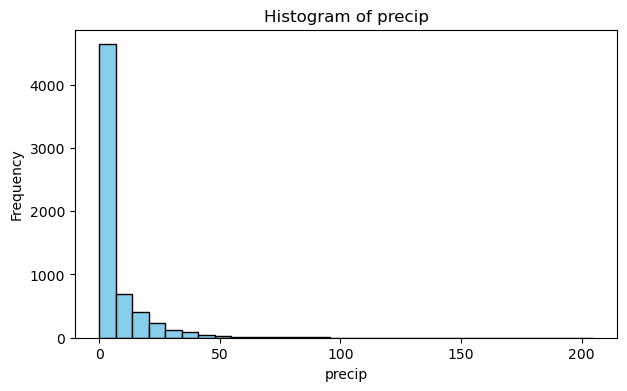

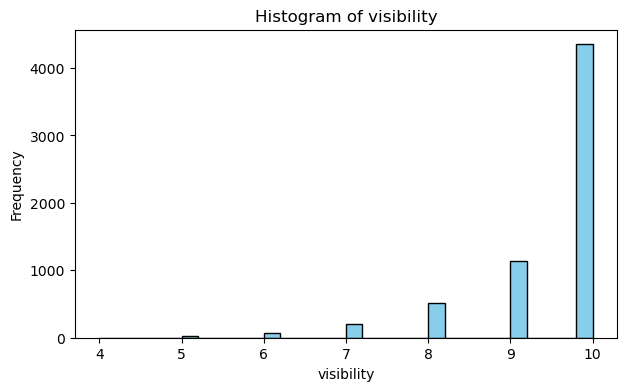

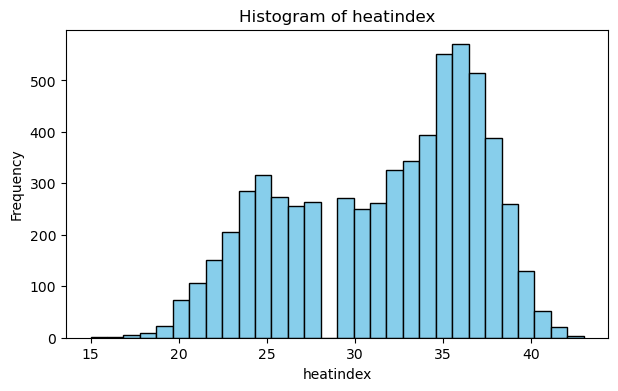

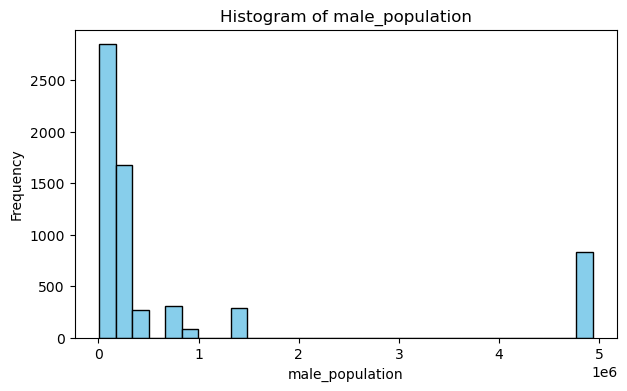

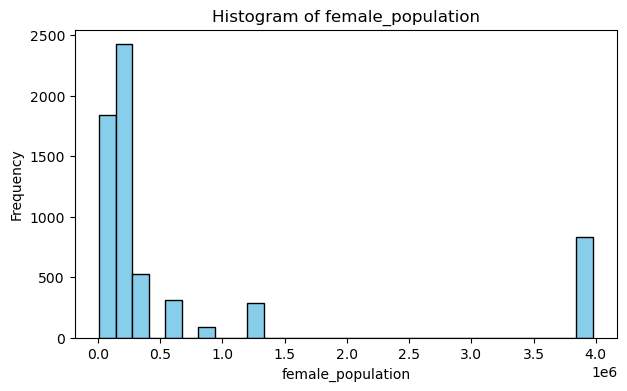

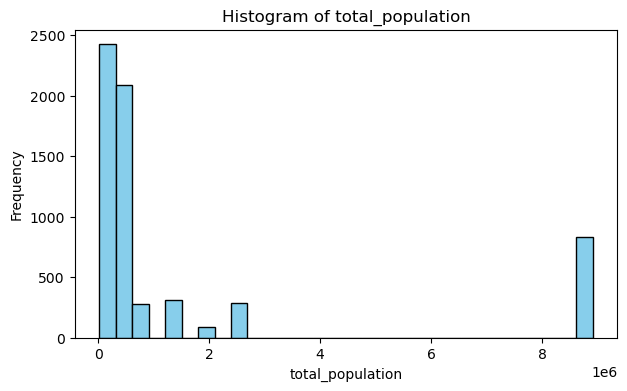

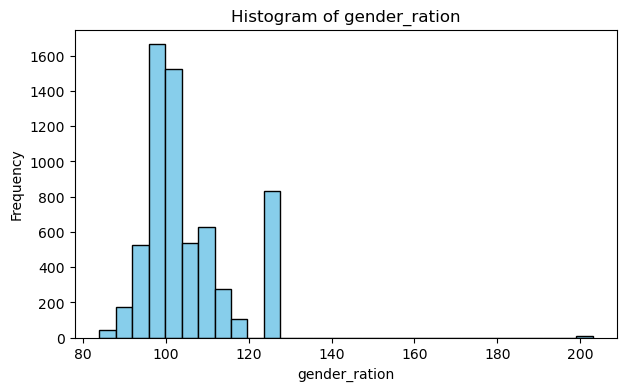

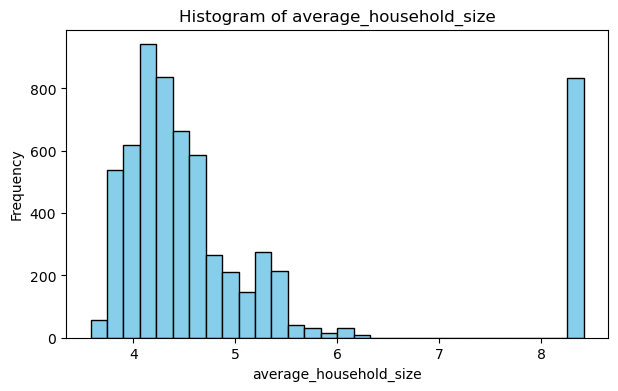

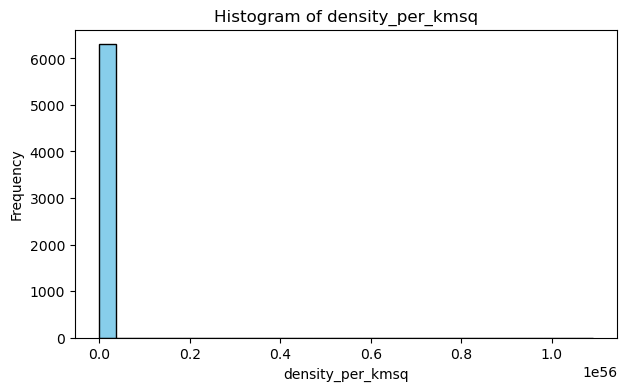

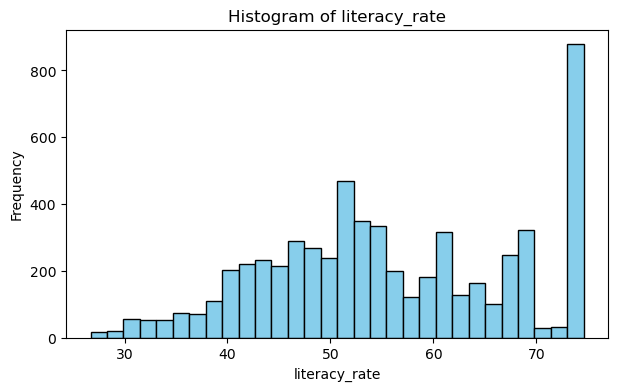

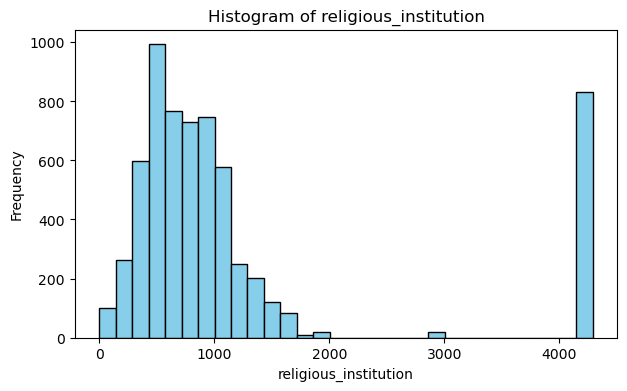

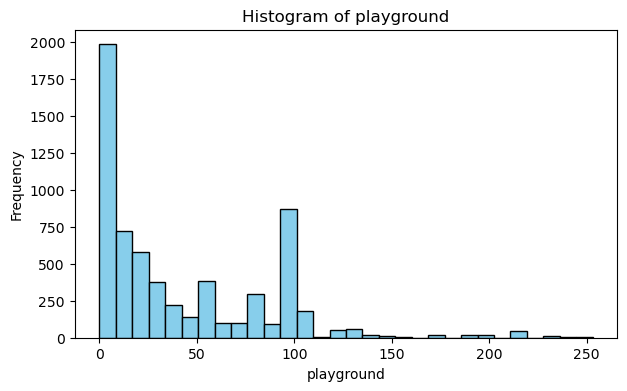

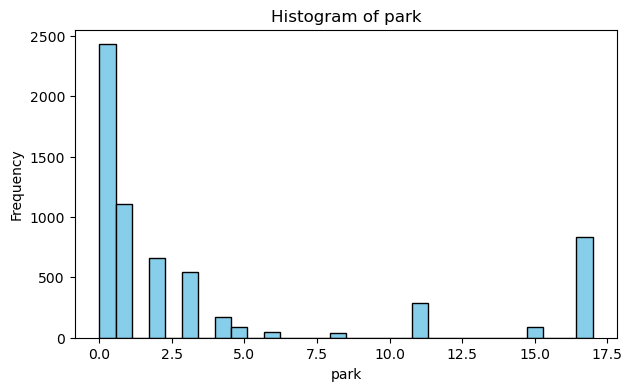

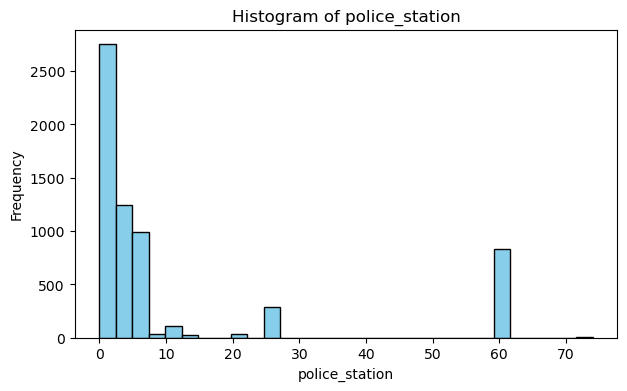

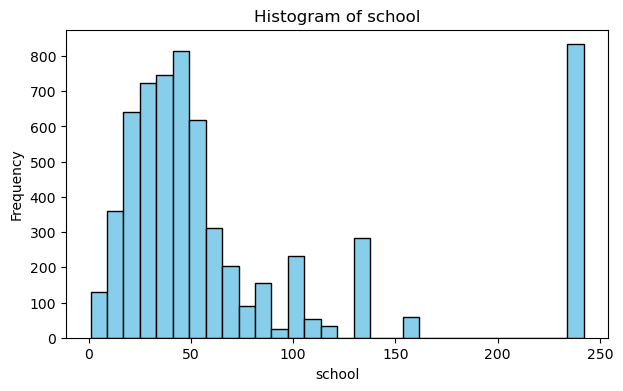

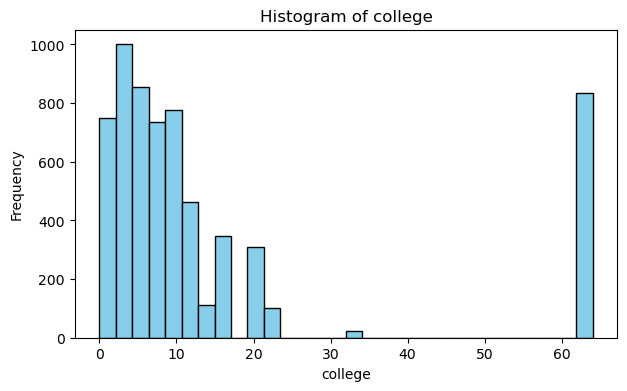

In [23]:
for col in num_col:
    data = df2[col].dropna()
    
    plt.figure(figsize=(7, 4))
    plt.hist(data, bins=30, color='skyblue', edgecolor='black')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

Semua variable numerik tidak terdistribusi normal, hal ini dipengaruhi karena banyaknya outlier sehingga distribusi tertarik ke arah outlier

## Missing Values

In [24]:
df3.isnull().sum()

incident_month            645
incident_week               0
incident_weekday            0
weekend                     0
part_of_the_day           115
incident_district         323
incident_division           0
precip                      0
visibility                  0
heatindex                   0
season                      0
male_population             0
female_population           0
total_population            0
gender_ration               0
average_household_size      0
density_per_kmsq            0
literacy_rate             323
religious_institution       0
playground                  0
park                        0
police_station              0
school                      0
college                     0
crime                       0
dtype: int64

Untuk impute missing values di incident_month, kita bisa menggunakan incident_week, dimana week 1-4 berarti milik month 1, dst. Namun agar lebih sesuai dengan dataset, kita akan coba groupby dan lihat untuk minggu sekian masuk ke bulan apa. Lalu baru impute berdasarkan hasil tersebut.

In [25]:
week_to_month_map = df3.groupby('incident_week')['incident_month'].median().to_dict()
df3['incident_month'] = df3['incident_month'].fillna(df3['incident_week'].map(week_to_month_map))

In [26]:
df3.isnull().sum()

incident_month              0
incident_week               0
incident_weekday            0
weekend                     0
part_of_the_day           115
incident_district         323
incident_division           0
precip                      0
visibility                  0
heatindex                   0
season                      0
male_population             0
female_population           0
total_population            0
gender_ration               0
average_household_size      0
density_per_kmsq            0
literacy_rate             323
religious_institution       0
playground                  0
park                        0
police_station              0
school                      0
college                     0
crime                       0
dtype: int64

Untuk kolom part_of_the_day, missing values akan diisi dengan kategori baru, yaitu "Unknown". Pendekatan ini dipilih karena kedua kolom tersebut bersifat kategorikal dan merepresentasikan informasi kontekstual, bukan nilai numerik yang bisa diperkirakan secara akurat.

Pengisian menggunakan nilai modus tidak dilakukan karena berpotensi menimbulkan bias, terutama jika satu kategori jauh lebih dominan dibandingkan yang lain. Hal tersebut dapat menyebabkan pola kejadian terlihat seolah-olah lebih terkonsentrasi pada kategori tertentu, padahal sebagian data sebenarnya tidak memiliki informasi tersebut.

Dengan menggunakan kategori “Unknown”, informasi tentang ketidaklengkapan data tetap dipertahankan tanpa memaksakan asumsi tertentu, sehingga interpretasi dan profil hasil clustering menjadi lebih objektif dan mudah dipahami.

Untuk kolom incident_district akan diinput berdasarkan mode incident_division tetap sesuai dengan divisinya. Sedangkan row yang divisinya hanya di row tersebut, akan difill dengan unknown

In [27]:
df3['part_of_the_day'] = df3['part_of_the_day'].fillna('unknown')
df3['incident_district'] = df3['incident_district'].fillna(
    df3.groupby('incident_division')['incident_district'].transform(
        lambda x: x.mode()[0] if not x.mode().empty else 'Unknown'
    )
)

Untuk kolom literacy_rate saya akan menggunakan knn imputer, dibanding langsung menggunakan median atau mean agar data tidak bias serta tetap sesuai karakteristik data. Hal ini juga mendukung proses clustering.

In [ ]:
cols_knn = [
    'literacy_rate',
    'density_per_kmsq',
    'total_population',
    'average_household_size',
    'school',
    'college'
]

scaler = RobustScaler()
scaled = scaler.fit_transform(df3[cols_knn])

imputer = KNNImputer(n_neighbors=5)
imputed = imputer.fit_transform(scaled)

df3[cols_knn] = scaler.inverse_transform(imputed)

In [29]:
df3.isnull().sum()

incident_month            0
incident_week             0
incident_weekday          0
weekend                   0
part_of_the_day           0
incident_district         0
incident_division         0
precip                    0
visibility                0
heatindex                 0
season                    0
male_population           0
female_population         0
total_population          0
gender_ration             0
average_household_size    0
density_per_kmsq          0
literacy_rate             0
religious_institution     0
playground                0
park                      0
police_station            0
school                    0
college                   0
crime                     0
dtype: int64

## Visualisasi Insight

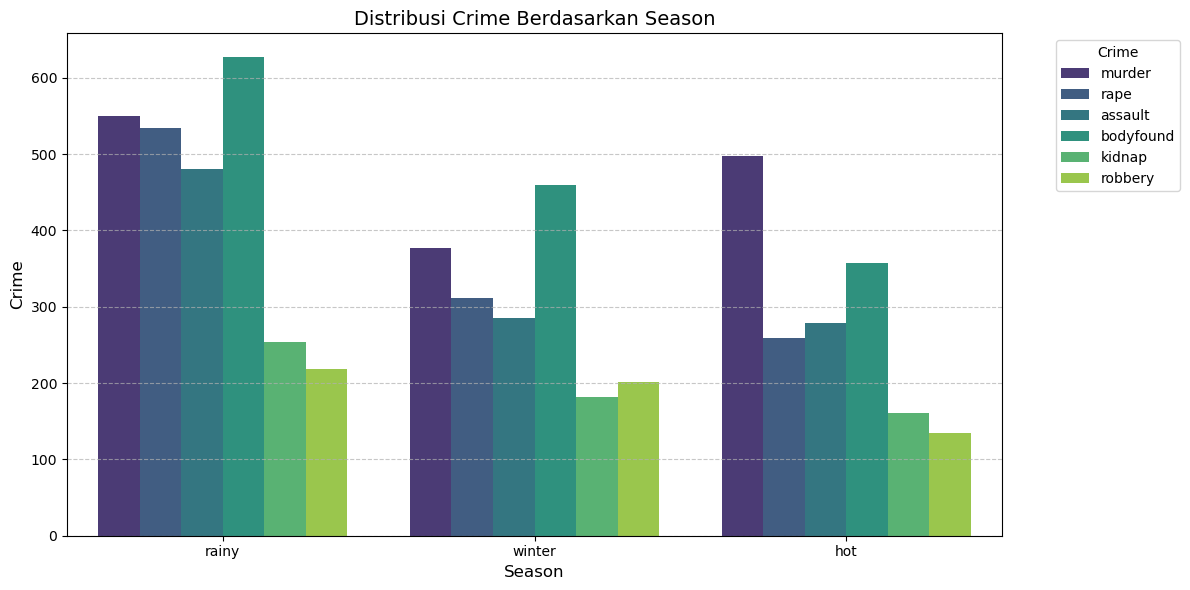

In [30]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df3, x='season', hue='crime', palette='viridis')

plt.title('Distribusi Crime Berdasarkan Season', fontsize=14)
plt.xlabel('Season', fontsize=12)
plt.ylabel('Crime', fontsize=12)
plt.legend(title='Crime', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Kriminalitas mencapai titik tertingginya pada Rainy Season (Musim Hujan), di mana kategori bodyfound dan murder melonjak signifikan dibandingkan musim lainnya. Fenomena ini mengindikasikan bahwa kondisi cuaca ekstrem atau berkurangnya mobilitas publik selama hujan mungkin dimanfaatkan pelaku untuk menyembunyikan jejak kejahatan, terutama karena angka penemuan mayat di musim ini adalah yang tertinggi. Sementara itu, kategori kejahatan seperti robbery dan kidnap cenderung lebih rendah dan stabil di semua musim, menunjukkan bahwa variasi musiman lebih berdampak pada kejahatan berat terhadap nyawa daripada kejahatan properti.

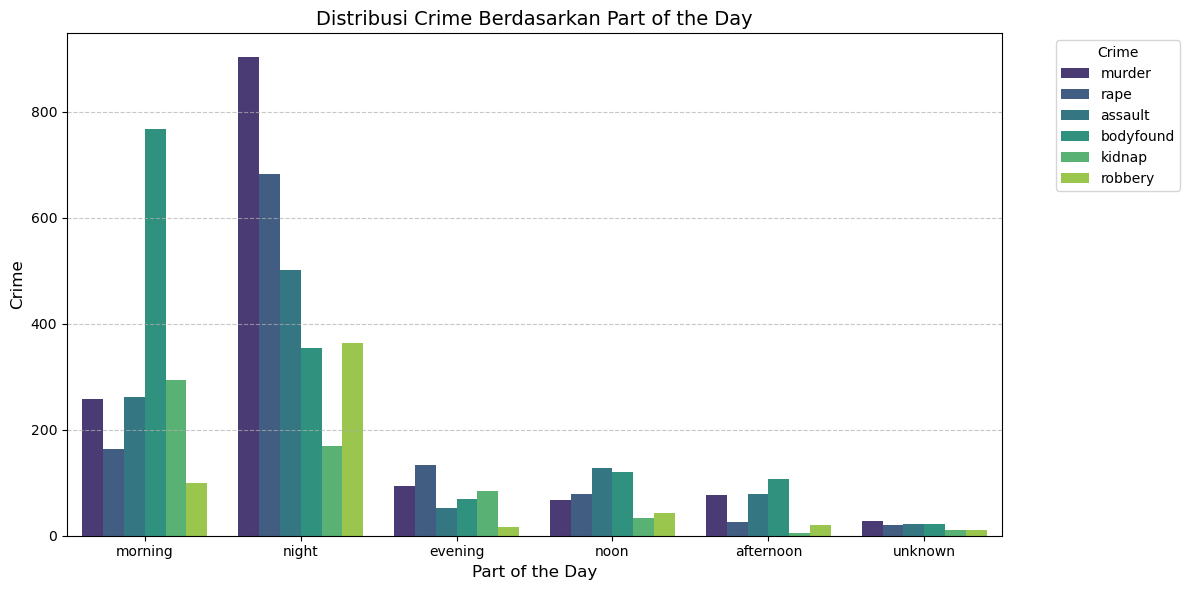

In [31]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df3, x='part_of_the_day', hue='crime', palette='viridis')

plt.title('Distribusi Crime Berdasarkan Part of the Day', fontsize=14)
plt.xlabel('Part of the Day', fontsize=12)
plt.ylabel('Crime', fontsize=12)
plt.legend(title='Crime', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Pola waktu menunjukkan malam hari (night) menjadi periode paling rawan dengan lonjakan kasus murder dan rape yang sangat drastis dibanding waktu lainnya. Ini mengindikasikan kurangnya pengawasan atau pemanfaatan kondisi gelap oleh pelaku untuk melakukan kejahatan. Menariknya, pada Pagi Hari (Morning), angka bodyfound tetap tinggi meskipun jenis kejahatan lainnya rendah. Hal ini menandakan bahwa banyak kejahatan yang terjadi di malam hari baru terdeteksi atau dilaporkan saat warga memulai aktivitas di pagi hari. Sebaliknya, waktu noon hingga evening mencatat angka kriminalitas terendah, hal ini menunjukkan bahwa kehadiran banyak orang dan cahaya matahari menjadi faktor pencegah yang kuat bagi para pelaku kriminal

## Check Correlation

In [32]:
num_var = df3.select_dtypes(include=['int64', 'float64'])
corr_matrix = num_var.corr()
corr_matrix

,incident_month,incident_week,weekend,precip,visibility,heatindex,male_population,female_population,total_population,gender_ration,average_household_size,density_per_kmsq,literacy_rate,religious_institution,playground,park,police_station,school,college
incident_month,1.000000,0.975878,-0.021582,0.118522,-0.151606,0.238411,0.014118,0.014243,0.014176,0.027952,0.001329,0.014224,0.016921,0.011795,0.022254,0.015825,0.009912,0.021306,0.017844
incident_week,0.975878,1.000000,-0.023388,0.120691,-0.154522,0.236635,0.013075,0.013144,0.013108,0.028867,0.002258,0.012434,0.016197,0.011233,0.023223,0.014339,0.009027,0.020033,0.017152
weekend,-0.021582,-0.023388,1.000000,-0.003283,0.007559,-0.030677,-0.000953,-0.000901,-0.000927,0.010614,-0.003733,0.003439,-0.005545,-0.003803,-0.006153,-0.003828,-0.000371,-0.011296,-0.007306
precip,0.118522,0.120691,-0.003283,1.000000,-0.817067,0.258594,-0.040888,-0.040552,-0.040741,-0.035016,-0.022004,-0.030227,-0.042284,-0.045908,-0.032080,-0.035784,-0.032667,-0.033438,-0.031568
visibility,-0.151606,-0.154522,0.007559,-0.817067,1.000000,-0.250815,0.036364,0.036026,0.036216,0.026330,0.016175,0.025786,0.045517,0.045317,0.031263,0.030005,0.026886,0.032435,0.032283
heatindex,0.238411,0.236635,-0.030677,0.258594,-0.250815,1.000000,0.029160,0.028688,0.028953,0.032847,-0.002671,0.019424,0.039718,0.035304,0.021512,0.028343,0.024000,0.026895,0.029485
male_population,0.014118,0.013075,-0.000953,-0.040888,0.036364,0.029160,1.000000,0.999810,0.999963,0.820374,0.927945,0.962368,0.676360,0.963723,0.505633,0.930010,0.984944,0.946143,0.974246
female_population,0.014243,0.013144,-0.000901,-0.040552,0.036026,0.028688,0.999810,1.000000,0.999941,0.821053,0.924838,0.965891,0.680571,0.963226,0.507816,0.933514,0.985801,0.949293,0.974177
total_population,0.014176,0.013108,-0.000927,-0.040741,0.036216,0.028953,0.999963,0.999941,1.000000,0.820715,0.926607,0.963978,0.678266,0.963548,0.506624,0.931610,0.985371,0.947588,0.974261
gender_ration,0.027952,0.028867,0.010614,-0.035016,0.026330,0.032847,0.820374,0.821053,0.820715,1.000000,0.695325,0.815025,0.643144,0.760438,0.404737,0.836393,0.807124,0.766784,0.790746


Total population berkolerasi dengan male population dan female population karena total merupakan hasil penjumlahan male dan female. Untuk itu, saya akan drop male dan female population. Selain itu, saya juga akan drop fitur yang berkolerasi tinggi > 0.9 karena Kmeans clustering sensitif dengan multicolinearity

In [33]:
df4 = df3.drop(columns=['male_population', 'female_population', 'park', 'college', 'school', 'police_station', 'religious_institution', 'incident_week', 'density_per_kmsq', 'average_household_size'])

In [34]:
num_var2 = df4.select_dtypes(include=['int64', 'float64'])
corr_matrix2 = num_var2.corr()
corr_matrix2

,incident_month,weekend,precip,visibility,heatindex,total_population,gender_ration,literacy_rate,playground
incident_month,1.000000,-0.021582,0.118522,-0.151606,0.238411,0.014176,0.027952,0.016921,0.022254
weekend,-0.021582,1.000000,-0.003283,0.007559,-0.030677,-0.000927,0.010614,-0.005545,-0.006153
precip,0.118522,-0.003283,1.000000,-0.817067,0.258594,-0.040741,-0.035016,-0.042284,-0.032080
visibility,-0.151606,0.007559,-0.817067,1.000000,-0.250815,0.036216,0.026330,0.045517,0.031263
heatindex,0.238411,-0.030677,0.258594,-0.250815,1.000000,0.028953,0.032847,0.039718,0.021512
total_population,0.014176,-0.000927,-0.040741,0.036216,0.028953,1.000000,0.820715,0.678266,0.506624
gender_ration,0.027952,0.010614,-0.035016,0.026330,0.032847,0.820715,1.000000,0.643144,0.404737
literacy_rate,0.016921,-0.005545,-0.042284,0.045517,0.039718,0.678266,0.643144,1.000000,0.456205
playground,0.022254,-0.006153,-0.032080,0.031263,0.021512,0.506624,0.404737,0.456205,1.000000


## Feature Engineering

In [35]:
df_model = df4.copy()

In [36]:
feat_enc = ['part_of_the_day', 'season', 'incident_weekday', 'incident_division', 'crime', 'incident_district']
ohe = OneHotEncoder(handle_unknown = "ignore", sparse_output = False)
feat_ohe =  ohe.fit_transform(df_model[feat_enc])

dfmodel_ohe = pd.DataFrame(feat_ohe, columns = ohe.get_feature_names_out(feat_enc), index = df_model.index)
df_model = df_model.drop(columns = feat_enc)
dfmodel_enc = pd.concat([df_model, dfmodel_ohe], axis = 1)


In [37]:
feat_log = ['precip', 'total_population']
for col in feat_log:
    dfmodel_enc[col] = np.log1p(dfmodel_enc[col])

In [38]:
scaler = RobustScaler()
dfmodel_scaled = scaler.fit_transform(dfmodel_enc)

In [39]:
pca = PCA(random_state=42)
pca.fit(dfmodel_scaled)

PCA(random_state=42)

Text(0.5, 1.0, 'Scree Plot (Zoomed In)')

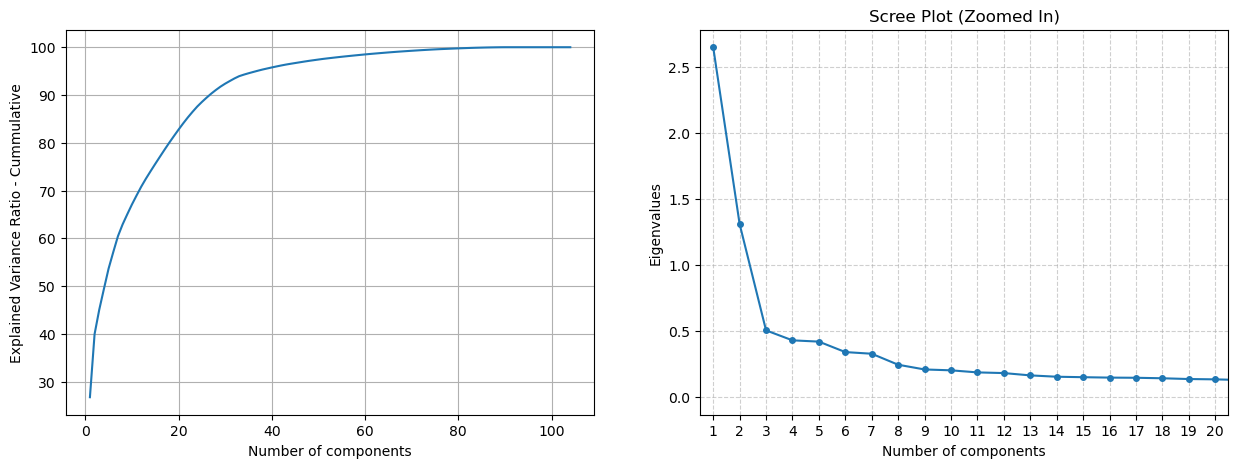

In [40]:
x_axis = np.arange(0, 30, 1)
explained_variance_ratio_cumsum = np.cumsum(pca.explained_variance_ratio_ * 100)

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.grid()
plt.plot(range(1, len(pca.explained_variance_ratio_)+1), explained_variance_ratio_cumsum)
plt.xlabel('Number of components')
plt.ylabel('Explained Variance Ratio - Cummulative')

plt.subplot(1, 2, 2)
plt.grid(True, linestyle='--', alpha=0.6) 
plt.plot(range(1, len(pca.explained_variance_) + 1), pca.explained_variance_, marker='o', markersize=4)

plt.xlim(0.5, 20.5) 
plt.xticks(range(1, 21)) 

plt.xlabel('Number of components')
plt.ylabel('Eigenvalues')
plt.title('Scree Plot (Zoomed In)')

Terlihat di Scree plot saat k=3, nilai eigenvalues sudah dibawah 1 yang berarti pada komponen 3, fitur yang bisa diwakilkan oleh PC3 tidak sebanyak itu. Oleh karena itu saya memilih komponen pca = 3. 

In [41]:
pca = PCA(n_components=3, random_state=42)
dfmodel_pca = pca.fit_transform(dfmodel_scaled)

# B) Modeling & Tuning

## Base model

In [42]:
base_kmeans = KMeans(n_clusters=3, random_state=42)
base_clusters = base_kmeans.fit_predict(dfmodel_pca)

print(f"Base Silhouette Score: {silhouette_score(dfmodel_pca, base_clusters)}")

Base Silhouette Score: 0.43531322325127136


## Tuning

For n_clusters = 2 | Inertia: 14176.56 | Silhouette_score: 0.5100
For n_clusters = 3 | Inertia: 9340.70 | Silhouette_score: 0.4353
For n_clusters = 4 | Inertia: 7212.59 | Silhouette_score: 0.4082
For n_clusters = 5 | Inertia: 5631.44 | Silhouette_score: 0.4199
For n_clusters = 6 | Inertia: 4845.01 | Silhouette_score: 0.4158
For n_clusters = 7 | Inertia: 4210.18 | Silhouette_score: 0.4169
For n_clusters = 8 | Inertia: 3727.91 | Silhouette_score: 0.4192
For n_clusters = 9 | Inertia: 3420.11 | Silhouette_score: 0.4139
For n_clusters = 10 | Inertia: 3095.05 | Silhouette_score: 0.3769


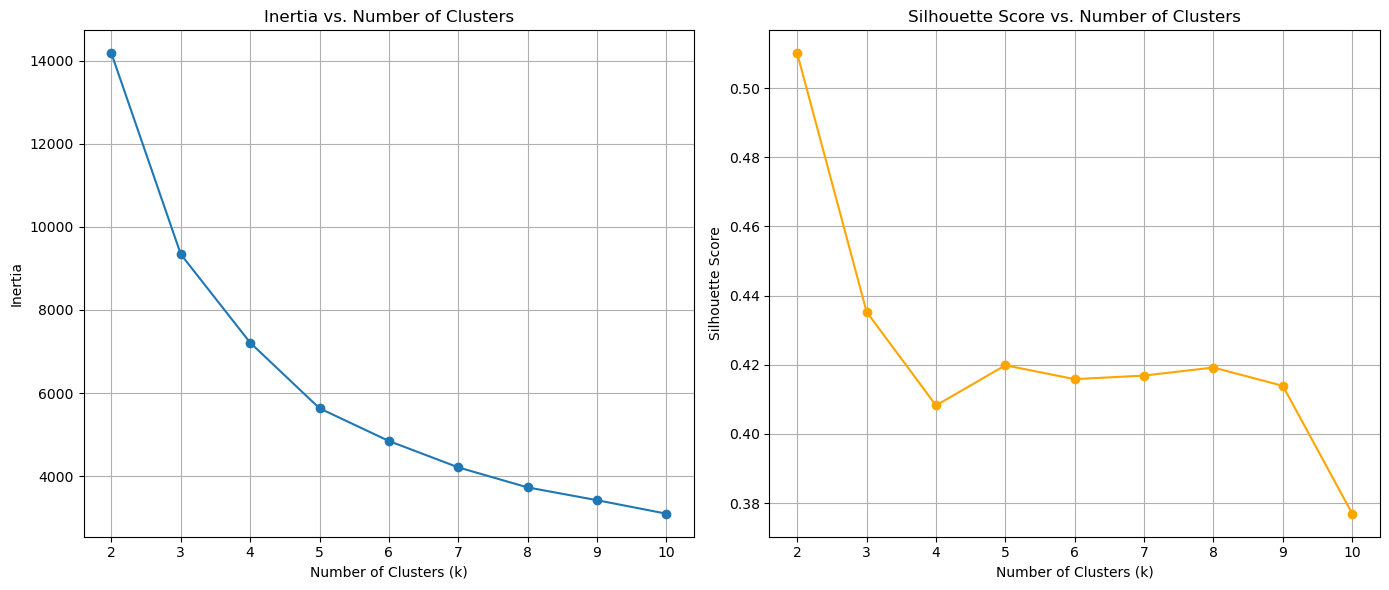

In [43]:
distortions = []
silhouettes = []
K = range(2,11)
for k in K:
    kmeanModel = KMeans(n_clusters=k, random_state=777)
    cluster_label = kmeanModel.fit_predict(dfmodel_pca)
    
    silhouette_sc = silhouette_score(dfmodel_pca, cluster_label)
    inertia_val = kmeanModel.inertia_
    
    print(
        f"For n_clusters = {k} | "
        f"Inertia: {inertia_val:.2f} | "
        f"Silhouette_score: {silhouette_sc:.4f}"
    )
    
    distortions.append(inertia_val)
    silhouettes.append(silhouette_sc)

plt.figure(figsize=(14, 6))

# inertia Plot
plt.subplot(1, 2, 1)
plt.plot(K, distortions, marker='o', label='Inertia')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Inertia vs. Number of Clusters')
plt.grid(True)

# silhouette Score Plot
plt.subplot(1, 2, 2)
plt.plot(K, silhouettes, marker='o', color='orange', label='Silhouette Score')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs. Number of Clusters')
plt.grid(True)

plt.tight_layout()
plt.show()

Meskipun nilai inertia terus menurun seiring bertambahnya jumlah cluster dan elbow inertia juga tampak mulai landai di k=3, namun elbow method subjektif dan membutuhkan silhouette score untuk konfirmasi. Terlihat bahwa nilai silhouette score mencapai nilai maksimum pada k = 2 dan menurun secara konsisten setelahnya. Hal ini menunjukkan bahwa solusi dua cluster memberikan keseimbangan terbaik antara homogenitas dalam cluster dan pemisahan antar cluster. Pada k = 3, nilai silhouette score menurun cukup signifikan dibandingkan k = 2, yang mengindikasikan adanya overlap karakteristik antar cluster. Oleh karena itu, meskipun k = 3 memberikan segmentasi yang lebih detail, kualitas clustering secara keseluruhan lebih baik pada k = 2.

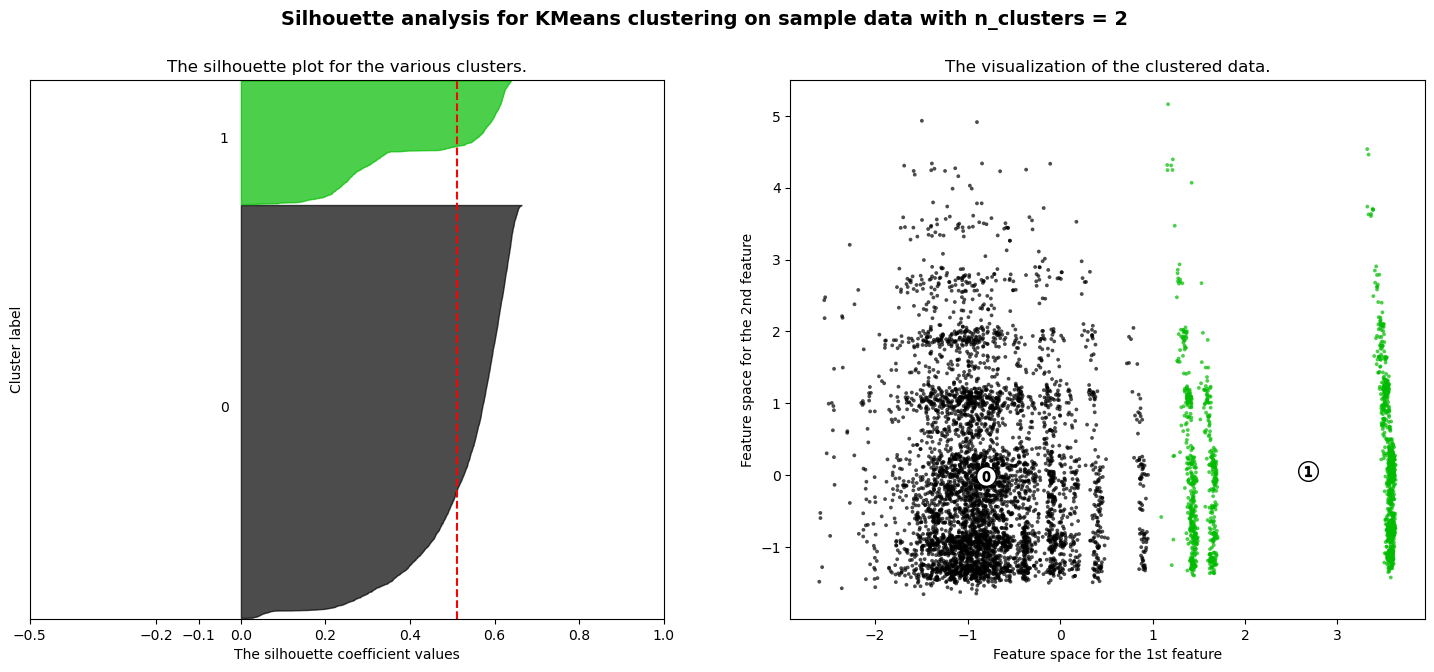

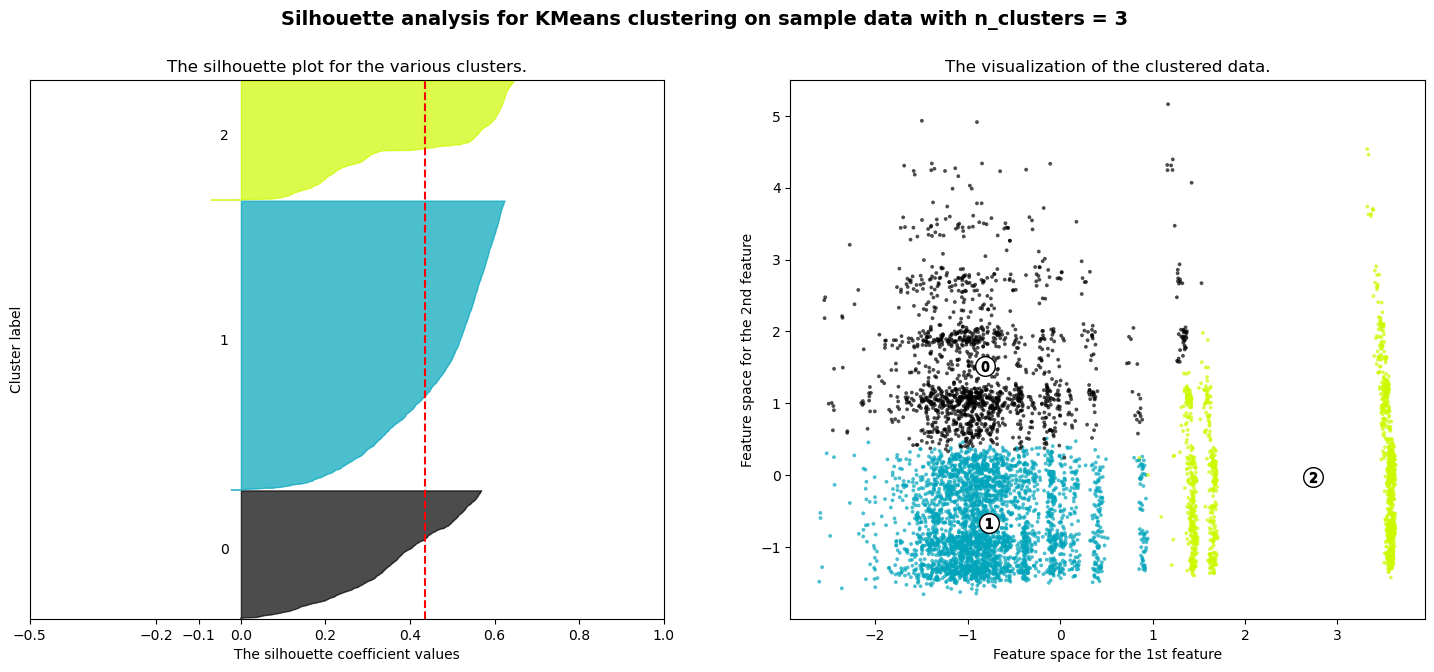

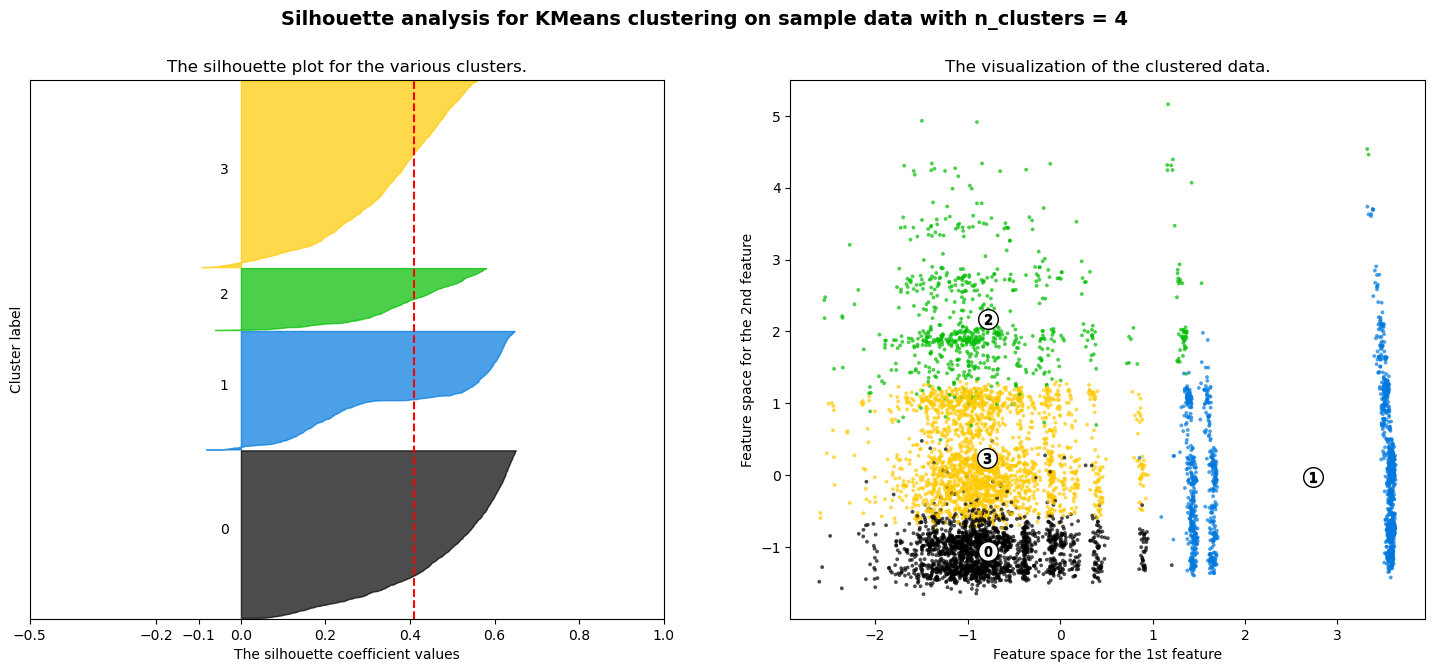

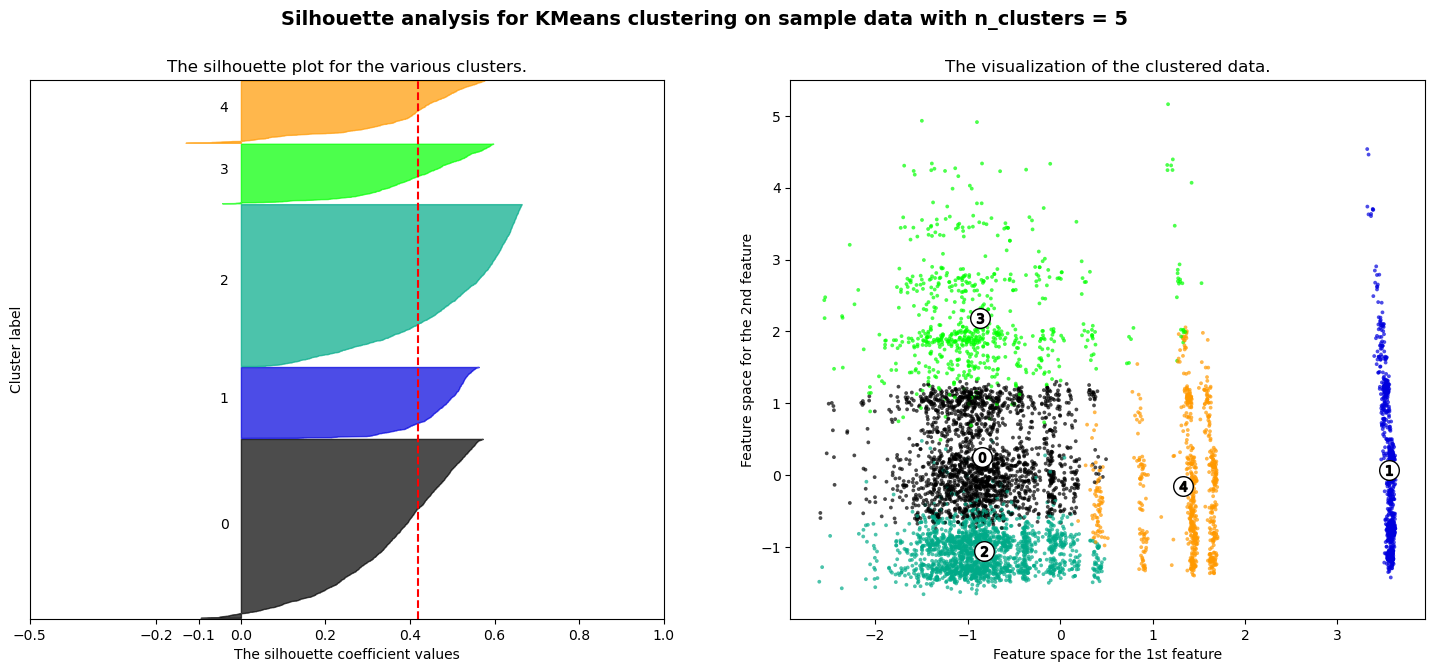

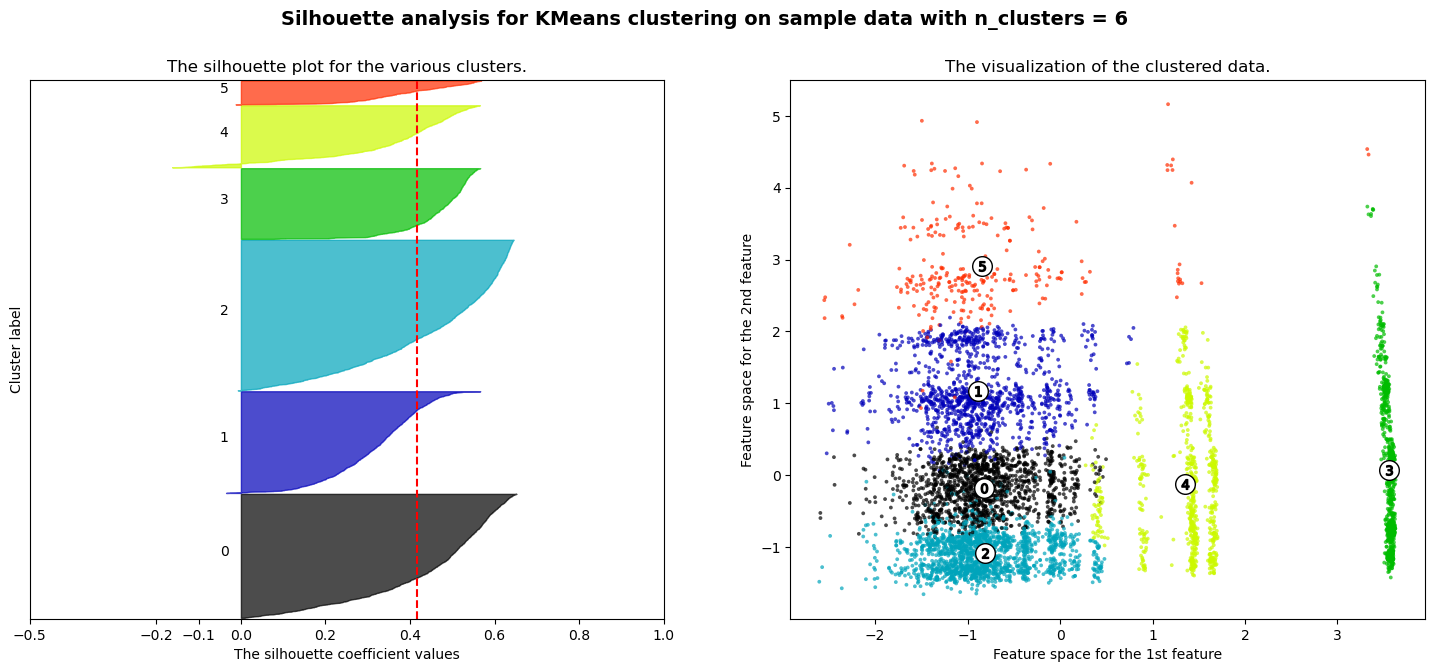

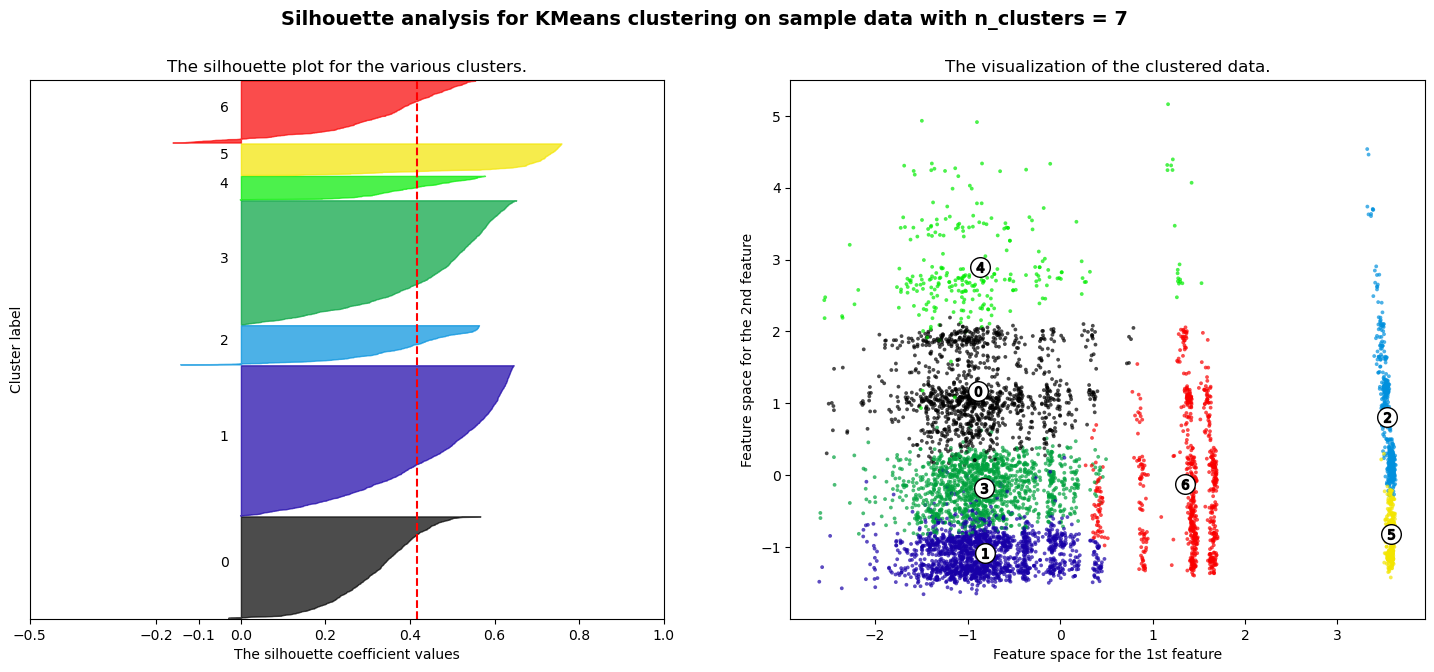

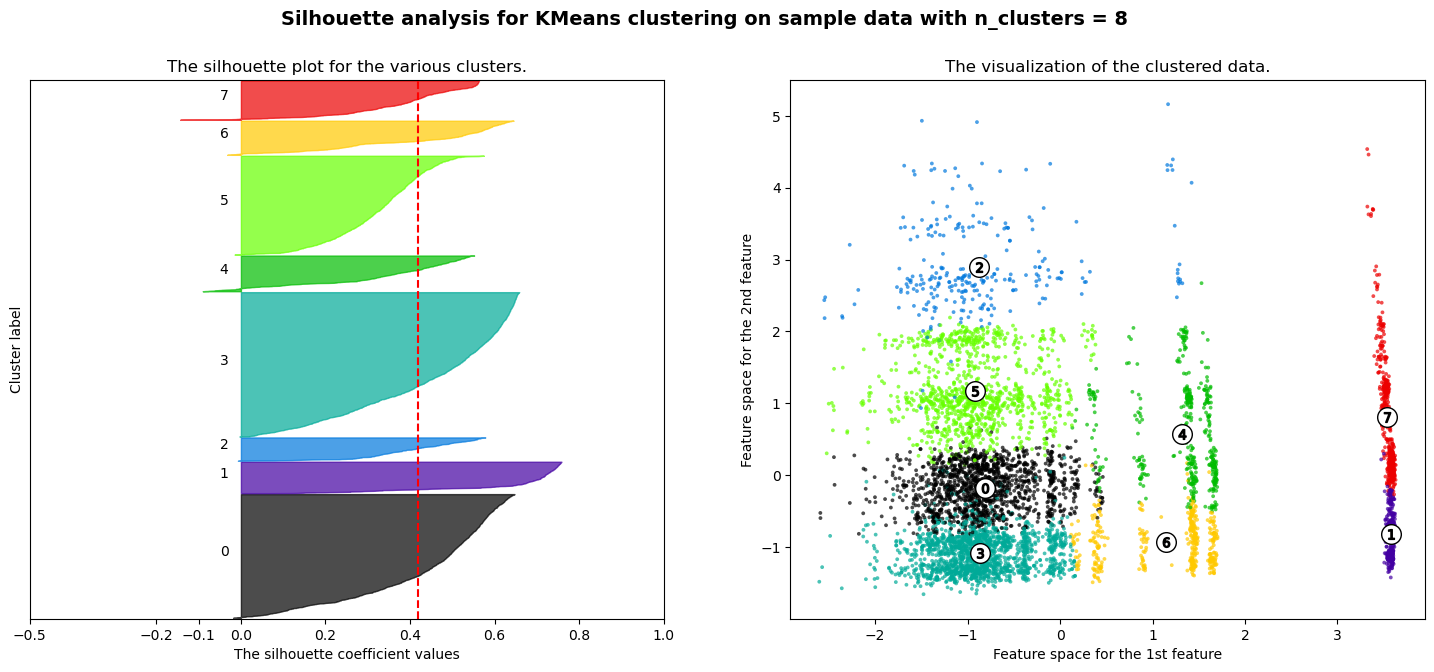

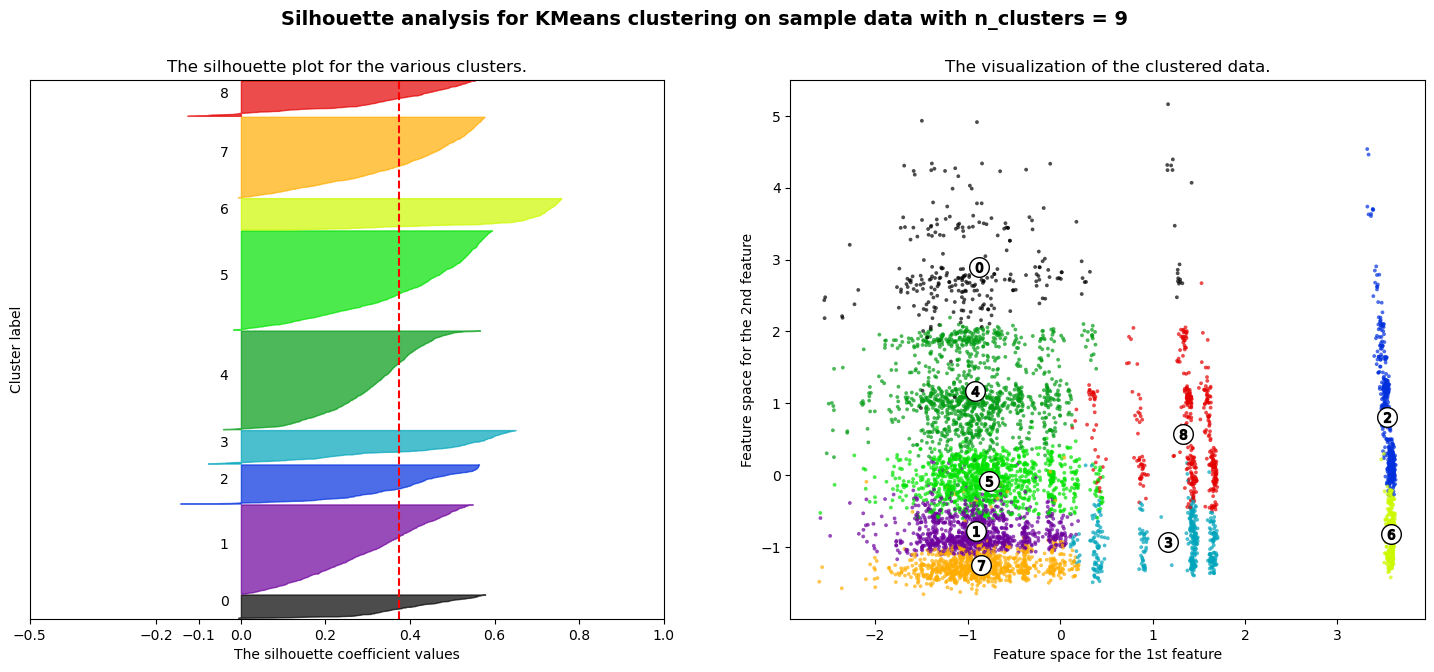

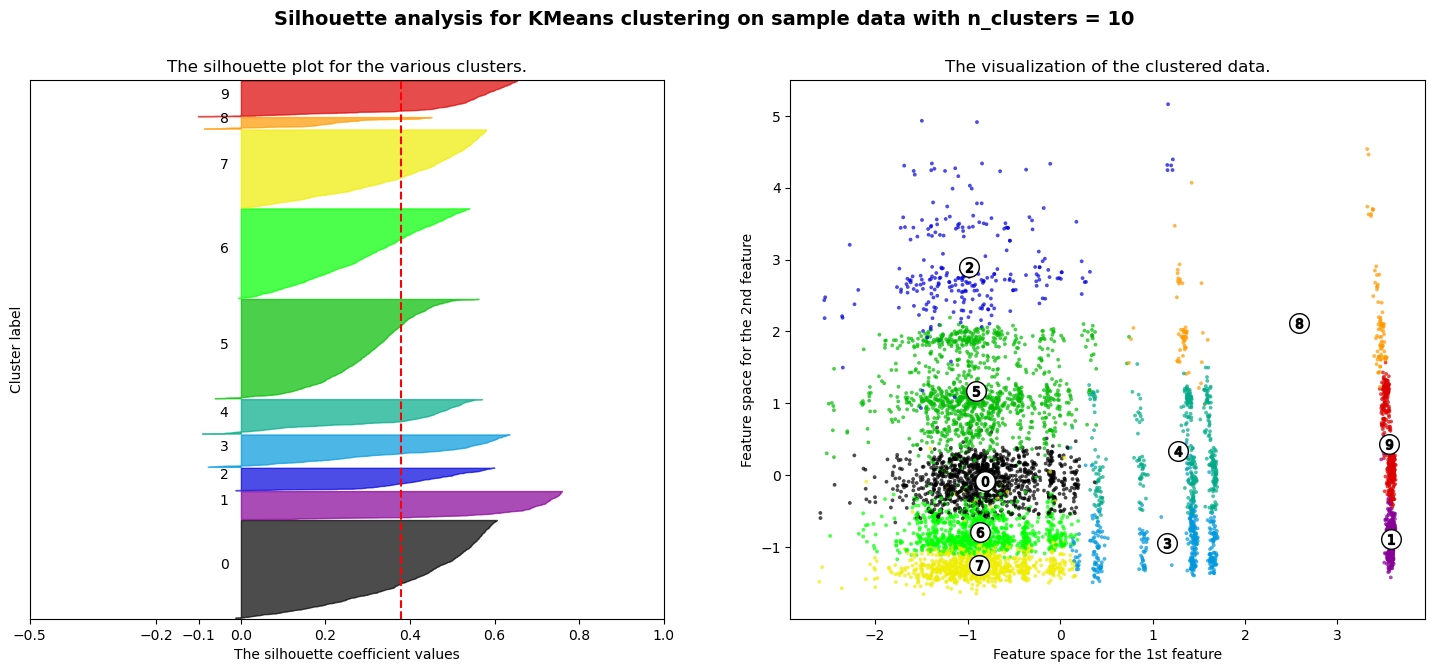

In [44]:
for n_clusters in K:
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    ax1.set_xlim([-0.5, 1])

    ax1.set_ylim([0, len(dfmodel_pca) + (n_clusters + 1) * 10])

    clusterer = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = clusterer.fit_predict(dfmodel_pca)

    silhouette_avg = silhouette_score(dfmodel_pca, cluster_labels)

    sample_silhouette_values = silhouette_samples(dfmodel_pca, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        y_lower = y_upper + 10

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  
    ax1.set_xticks([-0.5,-0.2,-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)

    pca_comp = PCA(n_components=4)
    df_pca_2 = pca_comp.fit_transform(dfmodel_scaled)

    ax2.scatter(
        df_pca_2[:, 0], df_pca_2[:, 1], marker=".", s=30, lw=0, alpha=0.7, c=colors, edgecolor="k"
    )

    centers = clusterer.cluster_centers_
    ax2.scatter(
        centers[:, 0],
        centers[:, 1],
        marker="o",
        c="white",
        alpha=1,
        s=200,
        edgecolor="k",
    )

    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], marker="$%d$" % i, alpha=1, s=50, edgecolor="k")

    ax2.set_title("The visualization of the clustered data.")
    ax2.set_xlabel("Feature space for the 1st feature")
    ax2.set_ylabel("Feature space for the 2nd feature")

    plt.suptitle(
        "Silhouette analysis for KMeans clustering on sample data with n_clusters = %d"
        % n_clusters,
        fontsize=14,
        fontweight="bold",
    )

plt.show()

Dari visualisasi di atas juga terlihat ketika jumlah kluster adalah 3, ada mis-clustering (Bagian warna ke arah negatif), sedangkan di 2 cluster tidak ada, sehingga saya memilih k = 2

In [45]:
model = KMeans(n_clusters = 2, random_state = 42)
pred = model.fit_predict(dfmodel_pca)
df_kmeans = df3.copy()
df_kmeans['cluster']=pred
pred

array([1, 1, 1, ..., 0, 0, 0])

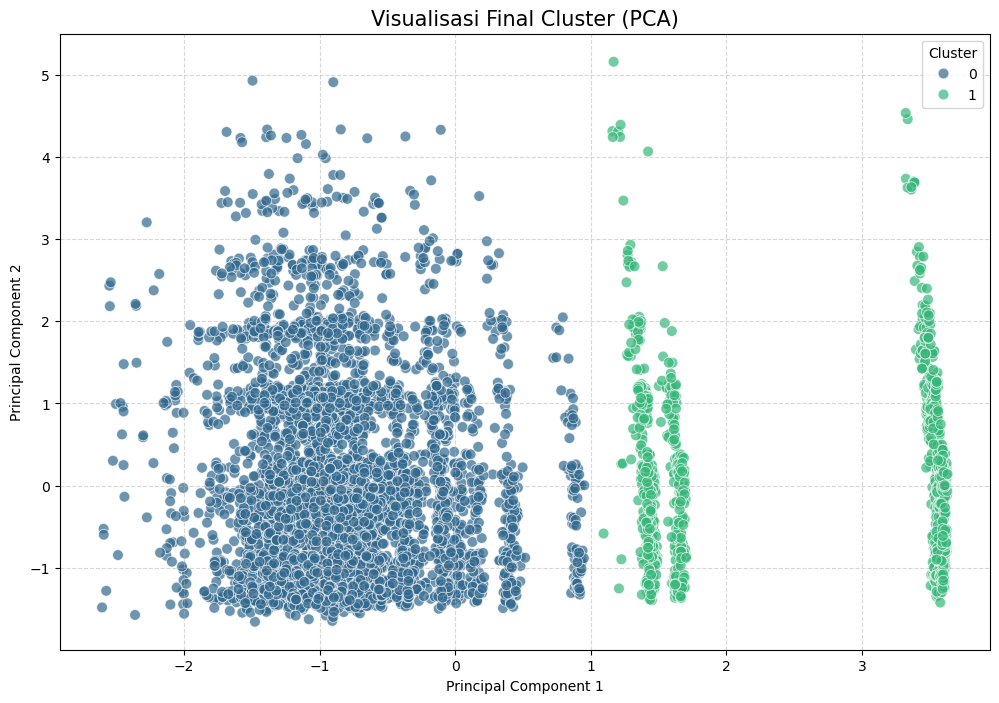

In [46]:
pca_df = pd.DataFrame(data = dfmodel_pca, 
                      columns = ['PC1', 'PC2', 'PC3'])
pca_df['cluster'] = df_kmeans['cluster'].values  # Masukkan label cluster hasil K-Means

# 5. Visualisasi Final
plt.figure(figsize=(12, 8))
sns.scatterplot(x='PC1', y='PC2', hue='cluster', data=pca_df, 
                palette='viridis', s=60, alpha=0.7, edgecolor='w')

plt.title('Visualisasi Final Cluster (PCA)', fontsize=15)
plt.xlabel(f'Principal Component 1')
plt.ylabel(f'Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Cluster', loc='upper right')
plt.show()

In [47]:
df_kmeans['cluster'].value_counts()

cluster
0    4749
1    1420
Name: count, dtype: int64

# C) Profiling Each Cluster

In [ ]:
for i in range(2):  
    print()
    print(f"Keunikan untuk Cluster {i}:")
    
    cluster_data = df_kmeans[df_kmeans['cluster'] == i]
    
    numeric_columns = cluster_data.select_dtypes(include=['int64', 'float64'])
    categorical_columns = cluster_data.select_dtypes(include=['object'])

    print("\nStatistik Deskriptif untuk Kolom Numerik:")
    print(numeric_columns.describe())
    
    print("\nMean per kolom numerik:")
    print(numeric_columns.mean())
    
    print("\nMode per kolom kategorikal:")
    for col in categorical_columns.columns:
        mode_value = categorical_columns[col].mode()[0] 
        mode_count = categorical_columns[col].value_counts().loc[mode_value] 
        print(f"{col}: Mode = {mode_value}, Count = {mode_count}")
    
    print("-" * 100)


Keunikan untuk Cluster 0:

Statistik Deskriptif untuk Kolom Numerik:


       incident_month  incident_week      weekend       precip   visibility  \
count     4749.000000    4749.000000  4749.000000  4749.000000  4749.000000   
mean         6.153506      25.024637     0.273110     6.488398     9.468730   
std          3.306738      14.461625     0.445604    12.377792     0.947507   
min          1.000000       1.000000     0.000000     0.000000     4.000000   
25%          3.000000      13.000000     0.000000     0.000000     9.000000   
50%          6.000000      25.000000     0.000000     0.800000    10.000000   
75%          9.000000      37.000000     1.000000     8.000000    10.000000   
max         12.000000      53.000000     1.000000   204.600000    10.000000   

         heatindex  male_population  female_population  total_population  \
count  4749.000000      4749.000000        4749.000000      4.749000e+03   
mean     31.528532    179705.784165      178896.467046      3.586180e+05   
std       5.568585    103349.061556       96669.863858      

**Cluster 0 – Wilayah Non-Metropolitan (Rural / Semi-Urban)**  
Cluster 0 merepresentasikan wilayah non-metropolitan atau semi-urban, yang dicirikan oleh jumlah penduduk relatif kecil hingga menengah, kepadatan penduduk yang tidak terlalu tinggi, serta tingkat literasi yang masih berada pada level menengah. Infrastruktur publik seperti sekolah, perguruan tinggi, taman, playground, dan kantor polisi tersedia dalam jumlah terbatas. Aktivitas kejadian paling sering terjadi pada malam hari, terutama di musim hujan, dengan jenis kejahatan yang dominan berupa murder. Karakteristik ini menggambarkan area yang belum padat secara urban, dengan keterbatasan fasilitas dan kapasitas pengawasan, sehingga masih menghadapi tantangan keamanan meskipun intensitas aktivitas sosial relatif lebih rendah dibanding wilayah metropolitan.

**Cluster 1 – Wilayah Metropolitan Perkotaan Padat**  
Cluster 1 mencerminkan wilayah metropolitan perkotaan yang sangat padat, dengan jumlah penduduk sangat besar, kepadatan penduduk ekstrem, serta tingkat literasi yang lebih tinggi. Wilayah ini memiliki infrastruktur publik yang jauh lebih lengkap, ditunjukkan oleh banyaknya sekolah, perguruan tinggi, tempat ibadah, taman, playground, dan kantor polisi. Kejadian paling sering terjadi pada malam hari, terutama di pusat kota seperti Dhaka, dengan jenis kasus dominan berupa body found. Karakteristik cluster ini menunjukkan dinamika kota besar dengan mobilitas tinggi, kompleksitas sosial yang lebih besar, serta tantangan keamanan yang khas akibat kepadatan dan intensitas aktivitas manusia yang sangat tinggi.